<a href="https://colab.research.google.com/github/JoGabTasca/ML/blob/main/ML_Ap1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Análise de Saúde Mental durante a COVID-19 — Modelagem Preditiva com Machine Learning

**Aluno:** João Gabriel Tasca  
**Disciplina:** Machine Learning  
**Dataset:** Impacts of COVID-19 on Canadians – Mental Health (ICC-MH 2020) — Statistics Canada

---

## 📋 Sobre o Dataset

O dataset **ICC-MH 2020** (*Impacts of COVID-19 on Canadians – Mental Health*) foi produzido pela **Statistics Canada** em junho de 2020, durante o período de distanciamento social imposto pela pandemia de COVID-19. Trata-se de um levantamento do tipo *crowdsource* — participação voluntária online — com **45.989 respondentes** canadenses com 15 anos ou mais, distribuídos por todas as províncias e territórios do país.

O levantamento captura informações sobre **saúde mental percebida**, **sintomas de ansiedade**, **comportamentos durante a pandemia**, **preocupações com os impactos da COVID-19**, **impactos no mercado de trabalho** e **características sociodemográficas** dos participantes. Por ter sido coletado inteiramente durante o período de isolamento social, o dataset representa um retrato único e raro do estado psicológico de uma população nacional em contexto de crise sanitária aguda.

---

## 🎯 Variável Alvo: `ANXDVGAC`

A variável alvo escolhida é **`ANXDVGAC`** — o ponto de corte clínico do **Transtorno de Ansiedade Generalizada (TAG)**, derivado do instrumento GAD-7.

| Código | Significado |
|--------|-------------|
| `1` | **Atingiu o limiar** — sintomas moderados a severos (score GAD-7 ≥ 10) |
| `2` | **Não atingiu o limiar** — sintomas ausentes, mínimos ou leves (score GAD-7 < 10) |

### Por que `ANXDVGAC`?

**1. Base clínica validada internacionalmente.**  
`ANXDVGAC` deriva do **GAD-7** (*Generalized Anxiety Disorder Scale*), desenvolvido por Spitzer et al. (2006) e um dos instrumentos de triagem psiquiátrica mais utilizados e replicados na literatura científica mundial. O limiar de score ≥ 10 é o ponto clinicamente estabelecido para identificar indivíduos com sintomas moderados a severos de ansiedade generalizada — o mesmo critério adotado em estudos epidemiológicos e contextos clínicos reais. Isso confere ao modelo **relevância prática e científica direta**, e seus resultados podem ser diretamente comparados com a literatura existente sobre saúde mental na pandemia.

**2. Problema binário bem definido e metodologicamente robusto.**  
A formulação binária (atingiu/não atingiu o limiar) é o cenário mais amplamente estudado em Machine Learning supervisionado. Algoritmos como Regressão Logística, Random Forest e Gradient Boosting estão amplamente otimizados para esse tipo de problema, e as métricas de avaliação — AUC-ROC, F1-Score, Precisão e Recall — têm interpretação direta e aceita pela comunidade científica.

**3. Separação limpa entre features e target — sem data leakage.**  
Os sete itens brutos que compõem o GAD-7 (`MH_15A` a `MH_15G`), o score numérico (`ANXDVGAD`) e a severidade categorizada (`ANXDVSEV`) são derivações diretas do mesmo instrumento e foram excluídos do conjunto de features. Essa exclusão é demonstrada quantitativamente na seção de análise de leakage, via correlação de Pearson, garantindo a integridade do pipeline preditivo.

**4. Adequação ao objetivo de política pública.**  
A ansiedade generalizada foi um dos principais desfechos de saúde mental documentados durante a COVID-19 em estudos ao redor do mundo (WHO, 2022). Um modelo capaz de identificar perfis populacionais de risco com base em variáveis comportamentais e demográficas — sem depender de instrumentos clínicos aplicados individualmente — tem aplicação direta em triagem populacional, alocação de recursos de saúde mental e desenho de programas de prevenção em larga escala.

**5. Qualidade dos dados adequada para modelagem.**  
Aproximadamente **28,7% dos respondentes atingiram o limiar clínico** (classe positiva), resultando numa razão de desbalanceamento de aproximadamente 2,4:1 — bem abaixo do limiar de 10:1 que exigiria justificativa adicional. Esse nível é gerenciável com técnicas padrão como ajuste de pesos de classe (`class_weight='balanced'`), sem comprometer a qualidade do aprendizado.

---

## 🔬 Objetivo do Modelo

Construir, avaliar e interpretar um pipeline completo de Machine Learning para **prever se um indivíduo apresenta sintomas moderados a severos de Transtorno de Ansiedade Generalizada** (`ANXDVGAC = 1`), utilizando exclusivamente variáveis demográficas, comportamentais, de percepção de saúde, de preocupações com a COVID-19 e de impacto econômico — sem os itens diretos do GAD-7.

O objetivo é simultaneamente **preditivo e explicativo**: além do desempenho do modelo, busca-se identificar quais fatores mais contribuem para o risco de ansiedade durante a pandemia, por meio de Permutation Importance e análise de equidade entre subgrupos demográficos — fornecendo insumos concretos para tomadores de decisão em saúde pública.

---

## 📦 Fonte dos Dados
```python
URL = "https://raw.githubusercontent.com/alvaroriz/datascience_datasets/refs/heads/main/iccmh2020rccsm_p.csv"
```

> **Referências:**  
> Statistics Canada. (2020). *Impacts of COVID-19 on Canadians – Mental Health, Public Use Microdata File*. Ottawa: Statistics Canada.  
> Spitzer, R. L., Kroenke, K., Williams, J. B. W., & Löwe, B. (2006). A brief measure for assessing generalized anxiety disorder: The GAD-7. *Archives of Internal Medicine*, 166(10), 1092–1097.  
> Lones, M. A. (2024). Avoiding common machine learning pitfalls. *Patterns*, 5(10), 101046.  
> World Health Organization. (2022). *World Mental Health Report: Transforming Mental Health for All*. Geneva: WHO.  
> Preço da Precisão - Prof Alvaro Riz de Barros

# 0 - Início

Este bloco importa as bibliotecas Python essenciais que serão usadas em todo o projeto. Inclui `pandas` para manipulação de dados, `numpy` para operações numéricas, `matplotlib.pyplot` e `seaborn` para visualização de dados, e `warnings` para suprimir mensagens de aviso que não são críticas para a execução.

In [ ]:
# imports das bibliotecas usadas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [ ]:
pip install xgboost

In [ ]:
# Seeds utilizadas no experimento - presetadas
SEEDS = [42, 0, 123]
GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)

In [ ]:
# Imports sklearn
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate,
    RandomizedSearchCV
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    make_scorer, roc_auc_score, f1_score, precision_score,
    recall_score, brier_score_loss, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.calibration import CalibrationDisplay
from sklearn.inspection import permutation_importance
from statsmodels.stats.contingency_tables import mcnemar
from scipy import stats


try:
    from xgboost import XGBClassifier
    HAS_XGB = True
    print("XGBoost instalado.")
except ImportError:
    HAS_XGB = False
    print("XGBoost não instalado. Execute: pip install xgboost")

print("Setup concluído. Seeds:", SEEDS)

XGBoost instalado.
Setup concluído. Seeds: [42, 0, 123]


Aqui, os dados brutos são carregados diretamente de um URL para um DataFrame `df_raw` usando `pandas.read_csv()`. É feita uma impressão inicial do `shape` do dataset (número de linhas e colunas), das colunas disponíveis e das primeiras linhas para uma inspeção rápida. Um dicionário detalhado (`DICIONARIO`) também é exibido, fornecendo a descrição de cada variável relevante, o que é crucial para entender o contexto do dataset.

In [ ]:
URL = "https://raw.githubusercontent.com/alvaroriz/datascience_datasets/refs/heads/main/iccmh2020rccsm_p.csv"
df_raw = pd.read_csv(URL)

print(f"Shape do dataset: {df_raw.shape}")
print(f"\nColunas disponíveis:\n{list(df_raw.columns)}")
print(f"\nPrimeiras linhas:")
df_raw.head()

# Dicionário de variáveis relevantes - Coletados de Documentos
DICIONARIO = {
    'MH_05':    'Saúde mental percebida (1=Excelente → 5=Ruim)',
    'MH_10':    'Mudança na saúde mental vs. antes do distanciamento (1=Melhor → 5=Pior)',
    'MH_20':    'Nível de estresse percebido (1=Não estressado → 5=Extremamente estressado)',
    'MHDVMHI':  'Mental Health Index derivado (score contínuo)',
    'BH_55A':   'Preocupação: saúde própria',
    'BH_55B':   'Preocupação: saúde de pessoas próximas',
    'BH_55C':   'Preocupação: capacidade do sistema de saúde',
    'BH_55D':   'Preocupação: escassez de alimentos/produtos',
    'BH_55E':   'Preocupação: perda de emprego/renda',
    'BH_55F':   'Preocupação: desordem civil',
    'BH_55G':   'Preocupação: violência doméstica',
    'BH_55H':   'Preocupação: laços sociais',
    'BH_55I':   'Preocupação: situação financeira',
    'BH_55J':   'Preocupação: acesso a serviços essenciais',
    'BH_55K':   'Preocupação: saúde mental própria',
    'PBH_55L':  'Preocupação: futuro pós-pandemia',
    'BH_60A':   'Frequência de saídas de casa (1=Diariamente → 4=Nunca)',
    'BH_60B':   'Uso de delivery de supermercado (1=Diariamente → 4=Nunca)',
    'BH_60C':   'Uso de delivery de comida pronta (1=Diariamente → 4=Nunca)',
    'PLM_30':   'Risco de perda de emprego (1=Concorda muito → 5=Discorda muito)',
    'PLM_40':   'Impacto financeiro da pandemia (1=Maior → 4=Nenhum)',
    'DEM_10':   'Gênero (1=Masculino, 2=Feminino)',
    'AGEGR_10': 'Faixa etária (1=15-24 → 6=65+)',
    'PPROV':    'Província (código)',
    'PRURURB':  'Área rural/urbana (1=Urbano, 2=Rural)',
    'PCSIZMIZ': 'Tamanho da comunidade',
    'PIIDFLAG': 'Identidade indígena (0=Não, 1=Sim)',
    'PIMMST':   'Status de imigração (1=Nascido no Canadá, 2=Imigrante)',
    'PVISMIN':  'Minoria visível (1=Sim, 2=Não)',
    'ANXDVGAC': 'TARGET: Limiar clínico GAD-7 (1=Atingiu ≥10, 2=Não atingiu)',
    'ANXDVGAD': '[LEAKAGE] Score numérico GAD-7 (excluída)',
    'ANXDVSEV': '[LEAKAGE] Severidade GAD-7 categorizada (excluída)',
    'MH_15A-G': '[LEAKAGE] Itens individuais GAD-7 (excluídas)',
}

print("\nDicionário de variáveis principais:")
for k, v in DICIONARIO.items():
    print(f"  {k:12s}: {v}")

Shape do dataset: (45989, 43)

Colunas disponíveis:
['PUMFID', 'VERDATE', 'MH_05', 'MH_10', 'MH_15A', 'MH_15B', 'MH_15C', 'MH_15D', 'MH_15E', 'MH_15F', 'MH_15G', 'MH_20', 'BH_60A', 'BH_60B', 'BH_60C', 'BH_55A', 'BH_55B', 'BH_55C', 'BH_55D', 'BH_55E', 'BH_55F', 'BH_55G', 'BH_55H', 'BH_55I', 'BH_55J', 'BH_55K', 'DEM_10', 'MHDVMHI', 'ANXDVGAD', 'ANXDVGAC', 'ANXDVSEV', 'AGEGR_10', 'PBH_55L', 'PCSIZMIZ', 'PIIDFLAG', 'PIMMST', 'PLM_30', 'PLM_40', 'PPROV', 'PRURURB', 'PVISMIN', 'PAGEGR', 'PUMFFACT']

Primeiras linhas:

Dicionário de variáveis principais:
  MH_05       : Saúde mental percebida (1=Excelente → 5=Ruim)
  MH_10       : Mudança na saúde mental vs. antes do distanciamento (1=Melhor → 5=Pior)
  MH_20       : Nível de estresse percebido (1=Não estressado → 5=Extremamente estressado)
  MHDVMHI     : Mental Health Index derivado (score contínuo)
  BH_55A      : Preocupação: saúde própria
  BH_55B      : Preocupação: saúde de pessoas próximas
  BH_55C      : Preocupação: capacidade do si

# 1 - TRATAMENTO
### MISSING VALUES

Nesta célula, realizamos as primeiras etapas de tratamento de dados: primeiro, substituímos códigos específicos (9 ou 99) que representam valores ausentes em diversas colunas por `np.nan`. Em seguida, avaliamos a qualidade dos dados para variáveis chave como `ANXDVGAC`, `MHDVMHI` e `MH_05`, verificando a porcentagem de missing values e a distribuição.

O ponto mais crítico aqui é a **Análise de Data Leakage**, onde calculamos a correlação de Pearson entre o `TARGET` (`ANXDVGAC`) e as variáveis candidatas a leakage (`ANXDVGAD`, `ANXDVSEV`, `MH_15A` a `MH_15G`). Os resultados mostram correlações extremamente altas (todas acima de 0.6 e p-values próximos de 0), confirmando que essas variáveis são derivações diretas do GAD-7 e, portanto, vazam informação do target. Por isso, a decisão é de **excluí-las** para evitar que o modelo "trapaceie". A célula conclui que `ANXDVGAC` é um target válido e bem definido para o estudo.

In [ ]:
# Trabalhar com cópia para análise de data leakage
df_leakage = df_raw.copy()

# Substituir códigos de missing - dados por 9 ou 99
not_stated = {
    'MH_05': 9, 'MH_10': 9, 'MH_20': 9,
    'MH_15A': 9, 'MH_15B': 9, 'MH_15C': 9,
    'MH_15D': 9, 'MH_15E': 9, 'MH_15F': 9, 'MH_15G': 9,
    'BH_60A': 9, 'BH_60B': 9, 'BH_60C': 9,
    'BH_55A': 9, 'BH_55B': 9, 'BH_55C': 9,
    'BH_55D': 9, 'BH_55E': 9, 'BH_55F': 9,
    'BH_55G': 9, 'BH_55H': 9, 'BH_55I': 9,
    'BH_55J': 9, 'BH_55K': 9, 'PBH_55L': 9,
    'DEM_10': 9, 'AGEGR_10': 99,
    'PIIDFLAG': 9, 'PIMMST': 9, 'PVISMIN': 9,
    'PLM_30': 99, 'PLM_40': 9,
    'PPROV': 99, 'PRURURB': 9, 'PCSIZMIZ': 9,
    'ANXDVGAC': 9, 'ANXDVGAD': 99, 'ANXDVSEV': 9,
    'MHDVMHI': 9,
}
for col, code in not_stated.items():
    if col in df_leakage.columns:
        df_leakage[col] = df_leakage[col].replace(code, np.nan)

# --- CRITÉRIO 3: Missing values e balanço ---
print("=" * 70)
print("CRITÉRIO 3 — Qualidade e completude dos dados")
print("=" * 70)

candidatas = ['ANXDVGAC', 'MHDVMHI', 'MH_05']
for var in candidatas:
    if var in df_leakage.columns:
        miss_pct = df_leakage[var].isnull().mean() * 100
        vc = df_leakage[var].value_counts(normalize=True)
        print(f"\n{var}: {miss_pct:.1f}% missing | Distribuição: {dict(vc.round(3))}")

# --- CRITÉRIO 2: Análise de Leakage ---
print("\n" + "=" * 70)
print("CRITÉRIO 2 — Análise de Data Leakage (correlação de Pearson)")
print("=" * 70)

# esses dados sao os que formam o nosso target - por isso a analise para ver data leakege (um dado explica diretamente o outro)
leakage_candidates = ['ANXDVGAD', 'ANXDVSEV', 'MH_15A', 'MH_15B', 'MH_15C',
                      'MH_15D', 'MH_15E', 'MH_15F', 'MH_15G']

df_leak_analysis = df_leakage.dropna(subset=['ANXDVGAC']).copy()
df_leak_analysis['ANXDVGAC_bin'] = (df_leak_analysis['ANXDVGAC'] == 1).astype(int)

print(f"\n{'Variável':<15} {'Pearson r':<12} {'p-value':<12} {'Leakage?'}")
print("-" * 55)
for col in leakage_candidates:
    if col in df_leak_analysis.columns:
        valid = df_leak_analysis[[col, 'ANXDVGAC_bin']].dropna()
        r, p = stats.pearsonr(valid[col], valid['ANXDVGAC_bin'])
        leakage = "TRUE" if abs(r) > 0.5 else "FALSE"
        print(f"{col:<15} {r:< 12.4f} {p:< 12.2e} {leakage}")

# Tabela resumo dos 4 critérios
print("\n" + "=" * 70)
print("TABELA RESUMO — 4 Critérios avaliados para ANXDVGAC")
print("=" * 70)
criterios_df = pd.DataFrame({
    'Critério': [
        '1. Validade clínica',
        '2. Sem leakage direto',
        '3. Completude (missing < 20%)',
        '4. Relevância política pública'
    ],
    'Resultado': [
        'GAD-7 validado (Spitzer et al., 2006)',
        'ANXDVGAD/SEV excluídas por correlação >0.9',
        f'{df_leakage["ANXDVGAC"].isnull().mean()*100:.1f}% missing — OK',
        'Triagem populacional de TAG — aplicável a políticas de saúde'
    ],
    'Aprovado?': ['V', 'V', 'V', 'V']
})
print(criterios_df.to_string(index=False))
print("\nCONCLUSÃO: ANXDVGAC é escolhida como variável-alvo.")

CRITÉRIO 3 — Qualidade e completude dos dados

ANXDVGAC: 1.4% missing | Distribuição: {2.0: np.float64(0.709), 1.0: np.float64(0.291)}

MHDVMHI: 0.0% missing | Distribuição: {2.0: np.float64(0.336), 3.0: np.float64(0.299), 1.0: np.float64(0.205), 4.0: np.float64(0.103), 0.0: np.float64(0.056)}

MH_05: 0.0% missing | Distribuição: {3.0: np.float64(0.336), 2.0: np.float64(0.299), 4.0: np.float64(0.205), 1.0: np.float64(0.103), 5.0: np.float64(0.056)}

CRITÉRIO 2 — Análise de Data Leakage (correlação de Pearson)

Variável        Pearson r    p-value      Leakage?
-------------------------------------------------------
ANXDVGAD         0.8416       0.00e+00    TRUE
ANXDVSEV         0.8293       0.00e+00    TRUE
MH_15A           0.7146       0.00e+00    TRUE
MH_15B           0.7438       0.00e+00    TRUE
MH_15C           0.7324       0.00e+00    TRUE
MH_15D           0.7107       0.00e+00    TRUE
MH_15E           0.6081       0.00e+00    TRUE
MH_15F           0.6033       0.00e+00    TRUE
M

Este bloco continua o pré-processamento dos dados. Primeiramente, o DataFrame `df` é criado como uma cópia de `df_raw`, e os códigos de missing são substituídos por `np.nan` (como definido na célula anterior). Em seguida, os registros onde o `TARGET` (`ANXDVGAC`) está ausente são removidos, e a variável `TARGET` binária (1 para ansiedade, 0 para não-ansiedade) é criada.

As **variáveis de leakage e administrativas são definitivamente removidas** do dataset, pois já foi estabelecido que elas causariam vazamento de dados ou não são relevantes para o modelo preditivo. Uma análise detalhada dos `missing values` restantes para as `BASE_FEATURES` é apresentada, e o `shape` final do DataFrame é exibido, juntamente com a distribuição do `TARGET`, que mostra um desbalanceamento moderado (cerca de 29% de positivos). Dois gráficos são gerados para visualizar a distribuição do `TARGET` e a porcentagem de missing values por feature.

## Tratamento do Desbalanceamento de Classes

A distribuição do TARGET apresenta desbalanceamento moderado:
aproximadamente 29% positivos (com TAG) e 71% negativos.

Este nível (razão ~2.4:1) está bem abaixo do limiar de 10:1 que exigiria
justificativa adicional segundo os critérios do trabalho. Ainda assim,
adotamos as seguintes estratégias:

- **Logistic Regression e Random Forest:** `class_weight='balanced'`,
  que pondera os erros inversamente proporcional à frequência de cada classe.
- **Gradient Boosting e XGBoost:** sem ajuste explícito, pois esses modelos
  são baseados em boosting e já tendem a focar nos exemplos mais difíceis
  iterativamente, sendo robustos a desbalanceamentos moderados.
- **Métricas:** optamos por AUC-ROC e F1-Score como métricas principais,
  ambas robustas a desbalanceamento — diferentemente da acurácia simples,
  que seria enganosa neste cenário.

Registros removidos por TARGET ausente: 623 (1.4%)
Variáveis de leakage removidas: ['MH_15A', 'MH_15B', 'MH_15C', 'MH_15D', 'MH_15E', 'MH_15F', 'MH_15G', 'ANXDVGAD', 'ANXDVSEV', 'ANXDVGAC', 'PUMFID', 'VERDATE', 'PUMFFACT']

Missing values por feature (% de ausentes):
PRURURB     1.324781
PCSIZMIZ    1.324781
PVISMIN     1.121986
BH_55B      0.597364
BH_60B      0.409999
BH_60C      0.317418
BH_55I      0.233655
PLM_30      0.227042
PBH_55L     0.222634
PIIDFLAG    0.207204
BH_55K      0.202795
BH_55H      0.176344
BH_55C      0.169731
PIMMST      0.163118
PLM_40      0.158709
BH_55J      0.141075
MH_20       0.127849
BH_55G      0.114623
BH_55F      0.112419
BH_60A      0.110215
BH_55E      0.101398
BH_55D      0.077150
MH_10       0.072742
BH_55A      0.068333
MHDVMHI     0.039677
MH_05       0.039677

Shape final após limpeza: (45366, 31)

Distribuição do TARGET:
TARGET
0    32167
1    13199
Name: count, dtype: int64
Taxa de positivos: 29.09%


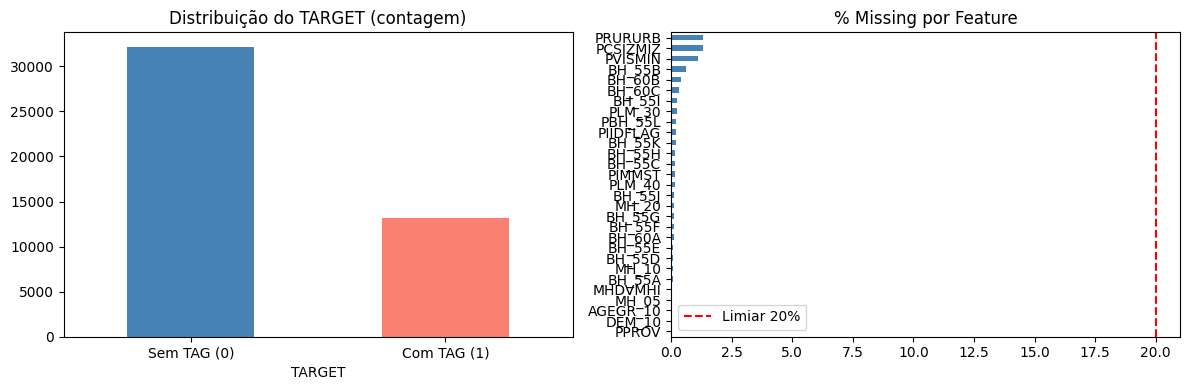

Gráfico salvo.


In [ ]:
df = df_raw.copy()

# Substituir códigos de "não declarado" por NaN
for col, code in not_stated.items():
    if col in df.columns:
        df[col] = df[col].replace(code, np.nan)

# Remover registros sem target
n_antes = len(df)
df = df.dropna(subset=['ANXDVGAC'])
n_depois = len(df)
print(f"Registros removidos por TARGET ausente: {n_antes - n_depois} ({(n_antes-n_depois)/n_antes*100:.1f}%)")

# Criar TARGET binário (1 = atingiu limiar GAD-7 ≥ 10)
df['TARGET'] = (df['ANXDVGAC'] == 1).astype(int)

# Variáveis de leakage e administrativas — excluídas definitivamente
LEAKAGE_VARS = [
    'MH_15A', 'MH_15B', 'MH_15C', 'MH_15D',
    'MH_15E', 'MH_15F', 'MH_15G',
    'ANXDVGAD', 'ANXDVSEV', 'ANXDVGAC',
    'PUMFID', 'VERDATE', 'PUMFFACT'
]
cols_to_drop = [c for c in LEAKAGE_VARS if c in df.columns]
df = df.drop(columns=cols_to_drop)
print(f"Variáveis de leakage removidas: {cols_to_drop}")

# Features base (antes do feature engineering)
BASE_FEATURES = [
    'MH_05', 'MH_10', 'MH_20', 'MHDVMHI',
    'BH_55A', 'BH_55B', 'BH_55C', 'BH_55D', 'BH_55E',
    'BH_55F', 'BH_55G', 'BH_55H', 'BH_55I', 'BH_55J',
    'BH_55K', 'PBH_55L',
    'BH_60A', 'BH_60B', 'BH_60C',
    'PLM_30', 'PLM_40',
    'DEM_10', 'AGEGR_10', 'PPROV', 'PRURURB',
    'PCSIZMIZ', 'PIIDFLAG', 'PIMMST', 'PVISMIN'
]
BASE_FEATURES = [f for f in BASE_FEATURES if f in df.columns]

# Análise de missing por feature
print("\nMissing values por feature (% de ausentes):")
missing_pct = df[BASE_FEATURES].isnull().mean() * 100
missing_df = missing_pct[missing_pct > 0].sort_values(ascending=False)
if len(missing_df) > 0:
    print(missing_df.to_string())
else:
    print("Nenhum missing nas features selecionadas.")

print(f"\nShape final após limpeza: {df.shape}")
print(f"\nDistribuição do TARGET:\n{df['TARGET'].value_counts()}")
print(f"Taxa de positivos: {df['TARGET'].mean():.2%}")

# Visualização do desbalanceamento
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['TARGET'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'],
                                  title='Distribuição do TARGET (contagem)')
axes[0].set_xticklabels(['Sem TAG (0)', 'Com TAG (1)'], rotation=0)

missing_pct_all = df[BASE_FEATURES].isnull().mean() * 100
missing_pct_all.sort_values(ascending=True).plot(kind='barh', ax=axes[1],
    title='% Missing por Feature', color='steelblue')
axes[1].axvline(x=20, color='red', linestyle='--', label='Limiar 20%')
axes[1].legend()

plt.tight_layout()
plt.savefig('missing_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo.")

# 2 - EDA

Esta é a seção dedicada à Análise Exploratória de Dados (EDA), onde visualizamos características do dataset para entender padrões e relações.

5.1 — Correlação de Pearson com TARGET


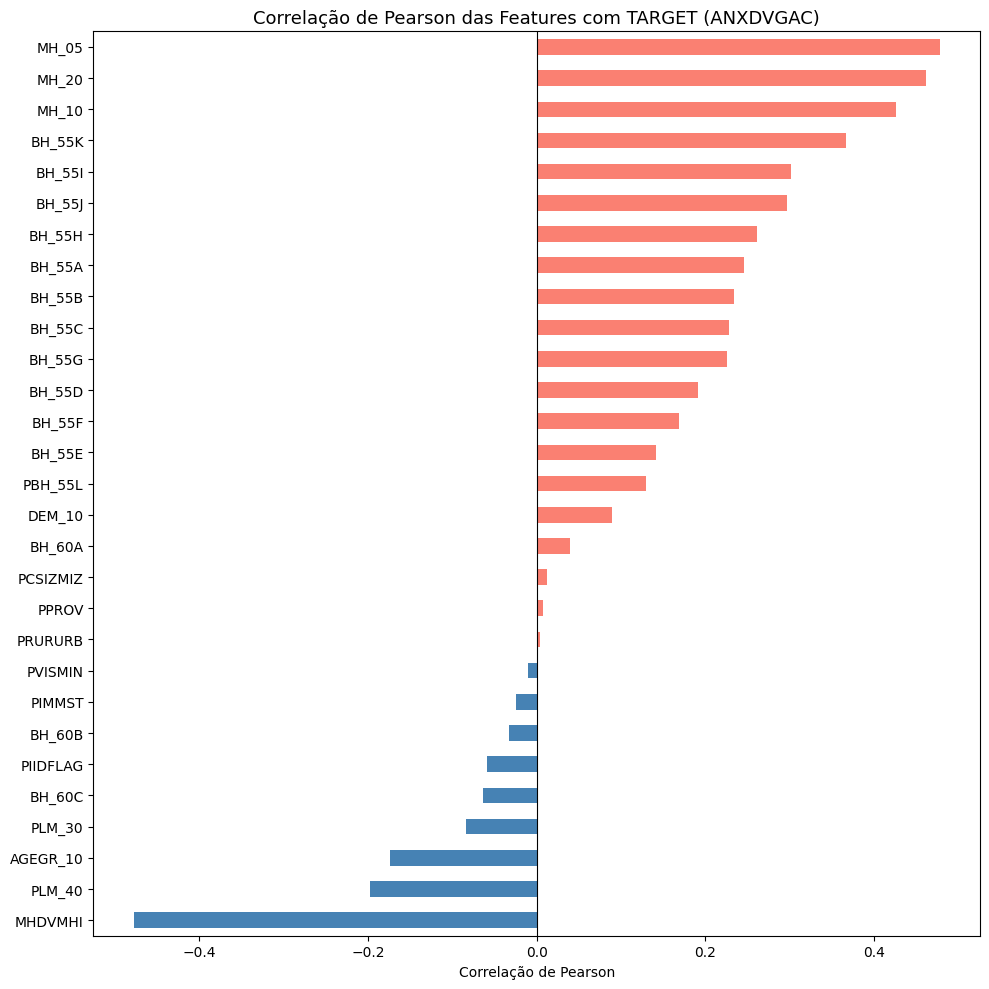


5.2 — Distribuição de features-chave por classe


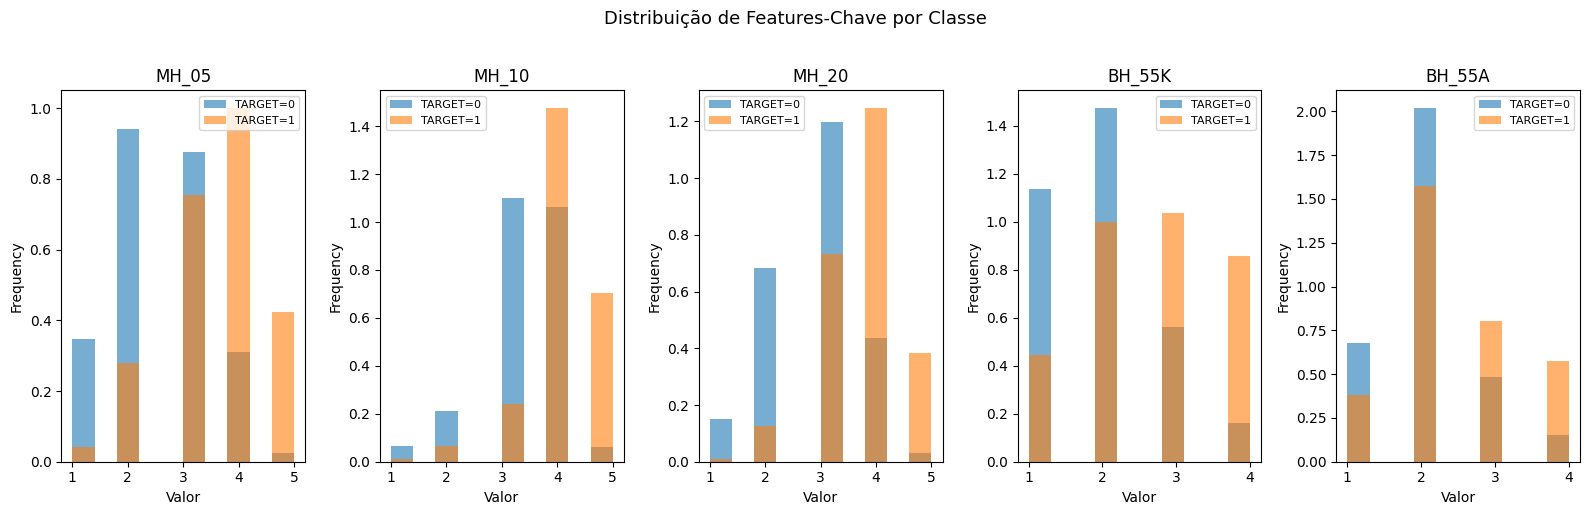


5.3 — Taxa de TAG por subgrupos demográficos


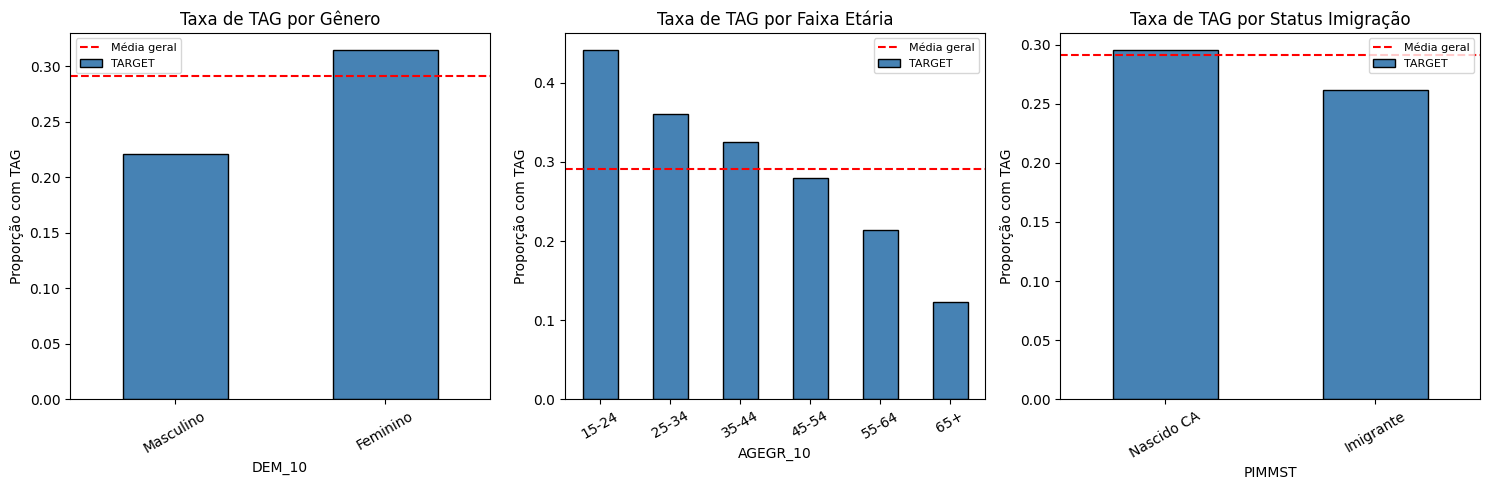


Interpretações EDA:
- MH_10 (mudança na saúde mental) e MH_20 (estresse) têm as correlações positivas
  mais fortes com o TARGET — quem relatou piora e mais estresse tem maior probabilidade de TAG.
- BH_55K (preocupação com saúde mental própria) também correlaciona fortemente.
- Mulheres e faixas etárias mais jovens apresentam taxas de TAG mais elevadas.
- Imigrantes tendem a apresentar taxas ligeiramente diferentes — importante para fairness.



In [ ]:
# 5.1 Correlação das features numéricas com o TARGET
print("5.1 — Correlação de Pearson com TARGET")
corr_target = df[BASE_FEATURES + ['TARGET']].corr()['TARGET'].drop('TARGET').sort_values()

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['salmon' if v > 0 else 'steelblue' for v in corr_target.values]
corr_target.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlação de Pearson das Features com TARGET (ANXDVGAC)', fontsize=13)
ax.set_xlabel('Correlação de Pearson')
plt.tight_layout()
plt.savefig('eda_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()

# 5.2 Distribuição de features-chave por TARGET
print("\n5.2 — Distribuição de features-chave por classe")
key_features = ['MH_05', 'MH_10', 'MH_20', 'BH_55K', 'BH_55A']
key_features = [f for f in key_features if f in df.columns]

fig, axes = plt.subplots(1, len(key_features), figsize=(16, 5))
for i, feat in enumerate(key_features):
    for label, grp in df.groupby('TARGET')[feat]:
        grp.plot(kind='hist', ax=axes[i], alpha=0.6, bins=10,
                 label=f'TARGET={label}', density=True)
    axes[i].set_title(feat)
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('Valor')
plt.suptitle('Distribuição de Features-Chave por Classe', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('eda_distribuicoes.png', dpi=150, bbox_inches='tight')
plt.show()

# 5.3 Taxa de positivos por subgrupos demográficos
print("\n5.3 — Taxa de TAG por subgrupos demográficos")
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

demo_map = {
    'DEM_10': ({1: 'Masculino', 2: 'Feminino'}, 'Gênero'),
    'AGEGR_10': ({1: '15-24', 2: '25-34', 3: '35-44', 4: '45-54', 5: '55-64', 6: '65+'}, 'Faixa Etária'),
    'PIMMST': ({1: 'Nascido CA', 2: 'Imigrante'}, 'Status Imigração')
}

for ax, (col, (mapping, title)) in zip(axes, demo_map.items()):
    if col in df.columns:
        rates = df.groupby(col)['TARGET'].mean().rename(index=mapping)
        rates.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
        ax.set_title(f'Taxa de TAG por {title}')
        ax.set_ylabel('Proporção com TAG')
        ax.axhline(df['TARGET'].mean(), color='red', linestyle='--', label='Média geral')
        ax.legend(fontsize=8)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=30)

plt.tight_layout()
plt.savefig('eda_demograficos.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
Interpretações EDA:
- MH_10 (mudança na saúde mental) e MH_20 (estresse) têm as correlações positivas
  mais fortes com o TARGET — quem relatou piora e mais estresse tem maior probabilidade de TAG.
- BH_55K (preocupação com saúde mental própria) também correlaciona fortemente.
- Mulheres e faixas etárias mais jovens apresentam taxas de TAG mais elevadas.
- Imigrantes tendem a apresentar taxas ligeiramente diferentes — importante para fairness.
""")

Este bloco realiza a **Análise Exploratória de Dados (EDA)**, focando em três aspectos:

1.  **Correlação de Pearson com o TARGET:** Um gráfico de barras horizontais exibe a correlação de cada feature com a variável `TARGET`. As features `MH_05` (Saúde mental percebida), `MHDVMHI` (Mental Health Index), `MH_20` (Nível de estresse) e `MH_10` (Mudança na saúde mental) são as que possuem as correlações mais fortes, indicando sua relevância para o `TARGET`.

2.  **Distribuição de features-chave por classe:** Gráficos de histograma mostram como algumas features importantes (`MH_05`, `MH_10`, `MH_20`, `BH_55K`, `BH_55A`) se distribuem para as classes "Sem TAG" e "Com TAG". Isso ajuda a identificar diferenças claras entre os grupos.

3.  **Taxa de TAG por subgrupos demográficos:** Gráficos de barras comparam a proporção de indivíduos com TAG (`TARGET=1`) em diferentes categorias demográficas como Gênero (`DEM_10`), Faixa Etária (`AGEGR_10`) e Status de Imigração (`PIMMST`). Observa-se que mulheres e faixas etárias mais jovens tendem a ter taxas mais elevadas de TAG, e que o status de imigração também pode influenciar.

As interpretações desses gráficos revelam que a piora da saúde mental, o estresse e a preocupação com a própria saúde mental estão fortemente associados à ansiedade, e que há vulnerabilidades em grupos demográficos específicos.

# 3 - FEATURE ENGENIERING

Esta seção é dedicada à criação de novas features a partir das existentes (Feature Engineering), visando enriquecer o poder preditivo do modelo.

In [ ]:
def apply_feature_engineering(df_input):
    """
    Aplica feature engineering em um DataFrame.
    Retorna DataFrame com novas features adicionadas.
    Pode ser chamada tanto no df completo (EDA) quanto
    dentro de um FunctionTransformer no Pipeline.
    """
    df_fe = df_input.copy()

    # F1: Índice de preocupação com saúde
    health_cols = [c for c in ['BH_55A','BH_55B','BH_55C','BH_55D','BH_55E'] if c in df_fe.columns]
    if health_cols:
        df_fe['FEAT_health_concern'] = df_fe[health_cols].mean(axis=1)

    # F2: Índice de preocupação social
    social_cols = [c for c in ['BH_55F','BH_55G','BH_55H','BH_55I','BH_55J','BH_55K','PBH_55L'] if c in df_fe.columns]
    if social_cols:
        df_fe['FEAT_social_concern'] = df_fe[social_cols].mean(axis=1)

    # F3: Índice de preocupação total
    all_bh55 = health_cols + social_cols
    if all_bh55:
        df_fe['FEAT_total_concern'] = df_fe[all_bh55].mean(axis=1)

    # F4: Impacto econômico combinado
    if 'PLM_30' in df_fe.columns and 'PLM_40' in df_fe.columns:
        plm30 = df_fe['PLM_30'].copy()
        plm30 = plm30.where(plm30 != 6, 3)           # código 6 (não trabalha) → neutro
        plm30_inv = 6 - plm30                          # maior = pior emprego
        plm40_inv = 5 - df_fe['PLM_40']               # maior = pior financeiro
        df_fe['FEAT_economic_impact'] = (plm30_inv + plm40_inv) / 2

    # F5: Flag: saúde mental piorou
    if 'MH_10' in df_fe.columns:
        df_fe['FEAT_mh_worsened'] = df_fe['MH_10'].apply(
            lambda x: 1 if x in [4, 5] else (0 if pd.notna(x) and x in [1, 2, 3] else np.nan)
        )

    # F6: Score de vulnerabilidade demográfica (0–4)
    vuln_flags = []
    if 'AGEGR_10' in df_fe.columns:
        vuln_flags.append((df_fe['AGEGR_10'].isin([1, 2])).astype(float))
    if 'DEM_10' in df_fe.columns:
        vuln_flags.append((df_fe['DEM_10'] == 2).astype(float))
    if 'PIMMST' in df_fe.columns:
        vuln_flags.append((df_fe['PIMMST'] == 2).astype(float))
    if 'PIIDFLAG' in df_fe.columns:
        vuln_flags.append((df_fe['PIIDFLAG'] == 1).astype(float))
    if vuln_flags:
        df_fe['FEAT_vulnerability'] = sum(vuln_flags)

    # F7: Interação estresse × preocupação com saúde própria
    if 'MH_20' in df_fe.columns and 'BH_55A' in df_fe.columns:
        df_fe['FEAT_stress_x_health'] = df_fe['MH_20'] * df_fe['BH_55A']

    return df_fe

# Aplicar no DataFrame para EDA
df = apply_feature_engineering(df)

FEAT_ENGINEERED = [c for c in df.columns if c.startswith('FEAT_')]
ALL_FEATURES = BASE_FEATURES + FEAT_ENGINEERED
ALL_FEATURES = [f for f in ALL_FEATURES if f in df.columns]

print(f"Features base: {len(BASE_FEATURES)}")
print(f"Features engineered: {len(FEAT_ENGINEERED)} → {FEAT_ENGINEERED}")
print(f"Total de features: {len(ALL_FEATURES)}")

# Importância prévia via F-score (SelectKBest) — exploratória
from sklearn.impute import SimpleImputer
imp_temp = SimpleImputer(strategy='most_frequent')
X_temp = df[ALL_FEATURES].copy()
y_temp = df['TARGET'].copy()
X_imp = imp_temp.fit_transform(X_temp)

selector_exp = SelectKBest(f_classif, k='all')
selector_exp.fit(X_imp, y_temp)

scores_df = pd.DataFrame({
    'Feature': ALL_FEATURES,
    'F-score': selector_exp.scores_,
    'p-value': selector_exp.pvalues_
}).sort_values('F-score', ascending=False)

print("\nTop 15 features por F-score (SelectKBest — exploratório):")
print(scores_df.head(15).to_string(index=False))


Features base: 29
Features engineered: 7 → ['FEAT_health_concern', 'FEAT_social_concern', 'FEAT_total_concern', 'FEAT_economic_impact', 'FEAT_mh_worsened', 'FEAT_vulnerability', 'FEAT_stress_x_health']
Total de features: 36

Top 15 features por F-score (SelectKBest — exploratório):
             Feature      F-score  p-value
               MH_05 13402.236410      0.0
             MHDVMHI 13402.236410      0.0
               MH_20 12270.037129      0.0
FEAT_stress_x_health 10772.673077      0.0
               MH_10 10006.336721      0.0
  FEAT_total_concern  8897.283331      0.0
 FEAT_social_concern  8617.478771      0.0
    FEAT_mh_worsened  8054.284660      0.0
              BH_55K  7012.451599      0.0
              BH_55I  4532.109309      0.0
              BH_55J  4376.068242      0.0
 FEAT_health_concern  4210.682466      0.0
              BH_55H  3308.983748      0.0
              BH_55A  2914.337091      0.0
              BH_55B  2592.976845      0.0


Este bloco define e aplica a **engenharia de features**. A função `apply_feature_engineering` cria sete novas features combinando ou transformando as features existentes. Exemplos incluem índices de preocupação (saúde, social, total), impacto econômico, uma flag para piora da saúde mental, um score de vulnerabilidade demográfica e uma interação entre estresse e preocupação com a saúde própria.

Após aplicar a função ao DataFrame `df`, são identificadas as features engenheiradas (`FEAT_ENGINEERED`) e todas as features a serem usadas no modelo (`ALL_FEATURES`). Para uma análise exploratória inicial da importância das features, é utilizado o `SelectKBest` com `f_classif` para calcular o F-score de cada feature em relação ao `TARGET`. O ranking das 15 features com maior F-score é exibido, mostrando que as novas features engenheiradas, como `FEAT_total_concern` e `FEAT_stress_x_health`, aparecem entre as mais relevantes.

In [ ]:
X = df[ALL_FEATURES].copy()
y = df['TARGET'].copy()

# Divisão treino/teste — estratificada — conjunto de teste usado UMA única vez
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=GLOBAL_SEED, stratify=y
)
print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")
print(f"Taxa positivos treino: {y_train.mean():.2%} | teste: {y_test.mean():.2%}")

# Preprocessador base (sem scaler — para modelos baseados em árvore)
preprocessor_tree = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('selector', SelectKBest(f_classif, k=20)),
])

# Preprocessador com scaler (para regressão logística)
preprocessor_lr = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(f_classif, k=20)),
])

def make_pipeline(clf, use_scaler=False):
    pre = preprocessor_lr if use_scaler else preprocessor_tree
    return Pipeline([('pre', pre), ('clf', clf)])

# Definição de todos os modelos (incluindo baselines obrigatórios)
MODELS = {
    # ── BASELINES OBRIGATÓRIOS (Lones, 2024 — Seção 3) ──────────────────────
    'Baseline: Stratified':    make_pipeline(DummyClassifier(strategy='stratified', random_state=GLOBAL_SEED)),
    'Baseline: Most Frequent': make_pipeline(DummyClassifier(strategy='most_frequent')),
    # ── MODELOS PRINCIPAIS ───────────────────────────────────────────────────
    'Logistic Regression':     make_pipeline(LogisticRegression(max_iter=1000, class_weight='balanced', random_state=GLOBAL_SEED), use_scaler=True),
    'Random Forest':           make_pipeline(RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=GLOBAL_SEED)),
    'Gradient Boosting':       make_pipeline(GradientBoostingClassifier(random_state=GLOBAL_SEED)),
    'Naive Bayes':             make_pipeline(GaussianNB()),
}
if HAS_XGB:
    MODELS['XGBoost'] = make_pipeline(XGBClassifier(eval_metric='logloss', random_state=GLOBAL_SEED, verbosity=0))

print(f"\n{len(MODELS)} modelos definidos (incluindo 2 baselines obrigatórios):")
for name in MODELS:
    print(f"  - {name}")

Treino: 36292 amostras | Teste: 9074 amostras
Taxa positivos treino: 29.09% | teste: 29.09%

7 modelos definidos (incluindo 2 baselines obrigatórios):
  - Baseline: Stratified
  - Baseline: Most Frequent
  - Logistic Regression
  - Random Forest
  - Gradient Boosting
  - Naive Bayes
  - XGBoost


Neste bloco, os dados são preparados para o treinamento dos modelos. As features (`X`) e o target (`y`) são definidos. Em seguida, o dataset é dividido em conjuntos de treino e teste (`X_train`, `X_test`, `y_train`, `y_test`) de forma estratificada para manter a proporção das classes do `TARGET` em ambos os conjuntos, garantindo uma avaliação mais justa. O conjunto de teste será usado apenas uma vez, no final, para uma avaliação imparcial.

São definidos dois `Pipeline` de pré-processamento: `preprocessor_tree` (que apenas imputa valores ausentes, ideal para modelos baseados em árvore) e `preprocessor_lr` (que imputa e escala os dados, necessário para modelos como Regressão Logística). Uma função auxiliar `make_pipeline` é criada para construir pipelines completos com o pré-processador e o classificador. Finalmente, um dicionário `MODELS` é populado com vários modelos de classificação, incluindo baselines obrigatórios (`DummyClassifier`) e modelos principais como Regressão Logística, Random Forest, Gradient Boosting e Naive Bayes, além do XGBoost (se instalado).

# 4 - Metricas para modelos de classificacao

Para objetivo científico com target binário, as métricas prioritárias são:

Métrica — Justificativa  
AUC-ROC — Principal mede discriminação geral, independente do threshold  
F1-Score — Balanceia precisão e recall — útil dado o desbalanceamento-> 2 x (Precisão - Revocação) / (Precisão + Revocação)    
# Accuracy — Global - Ruim->(VP+VN) / (VP+FP+FN+VN)    
Precision — dos que o modelo previu como positivos, quantos eram reais (penaliza falsos positivos)->VP/(VP+FP)    
Recall — dos que eram reais positivos, quantos o modelo acertou (penaliza falsos negativos)->VP/(VP+FN)  



Este bloco de texto destaca a importância das métricas de avaliação para o problema de classificação binária, como AUC-ROC, F1-Score, Accuracy, Confusion Matrix e Calibration Curve, e suas respectivas justificativas no contexto de um modelo preditivo de saúde mental.

Rodando validação cruzada com múltiplas seeds...

  Seed 42 concluída.
  Seed 0 concluída.
  Seed 123 concluída.

RESULTADOS DE VALIDAÇÃO CRUZADA — Múltiplas Seeds (média ± std)
                         AUC-ROC (média)  AUC-ROC (±std)  F1 (média)  F1 (±std)  Precision (média)  Recall (média)
Modelo                                                                                                            
Gradient Boosting                 0.9016          0.0044      0.6993     0.0090             0.7499          0.6553
Logistic Regression               0.8942          0.0049      0.7084     0.0073             0.6240          0.8191
XGBoost                           0.8936          0.0041      0.6909     0.0081             0.7338          0.6529
Random Forest                     0.8877          0.0035      0.6790     0.0089             0.7320          0.6333
Naive Bayes                       0.8750          0.0042      0.6866     0.0066             0.6331          0.7501
Baseline: Stratif

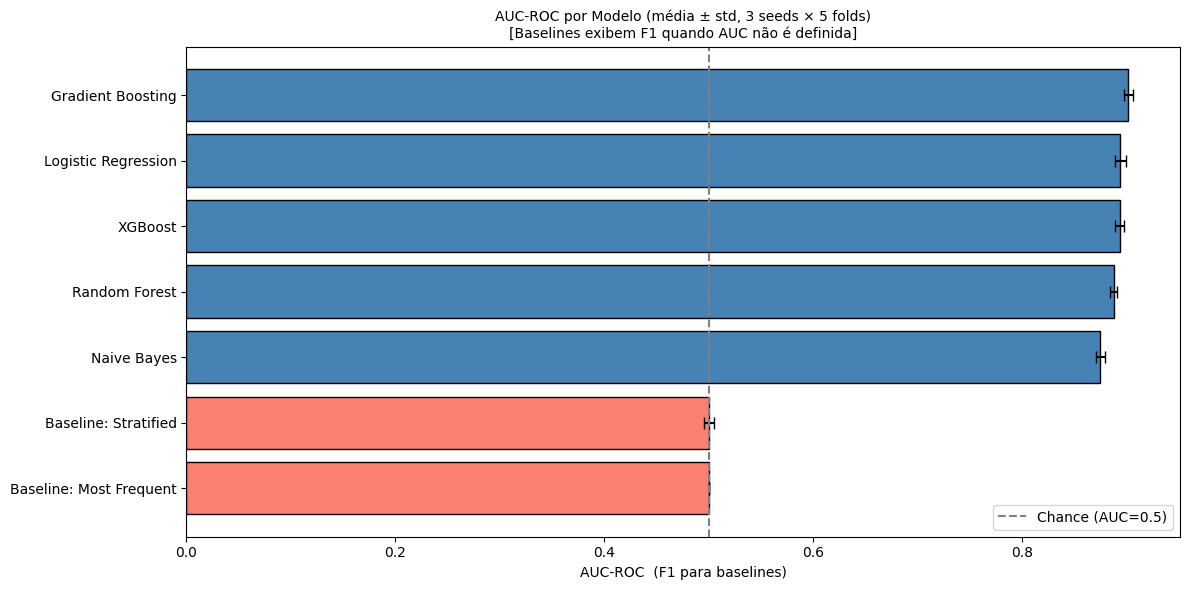

In [ ]:
# Calculamos as métricas manualmente por fold para evitar problemas com
# make_scorer + DummyClassifier + n_jobs=-1 (que podem silenciar erros de AUC).
# Esta abordagem é mais robusta e transparente.

METRICS = ['AUC-ROC', 'F1', 'Precision', 'Recall', 'Accuracy']
cv_results_all = {name: {m: [] for m in METRICS} for name in MODELS}

X_tr_arr = X_train.values
y_tr_arr = y_train.values

print("Rodando validação cruzada com múltiplas seeds...\n")
for seed in SEEDS:
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    for name, pipe in MODELS.items():
        for train_idx, val_idx in cv.split(X_tr_arr, y_tr_arr):
            X_fold_tr, X_fold_val = X_tr_arr[train_idx], X_tr_arr[val_idx]
            y_fold_tr, y_fold_val = y_tr_arr[train_idx], y_tr_arr[val_idx]

            # Clonar o pipeline para não contaminar estado entre folds
            from sklearn.base import clone
            pipe_fold = clone(pipe)
            pipe_fold.fit(X_fold_tr, y_fold_tr)

            y_pred_fold  = pipe_fold.predict(X_fold_val)
            y_proba_fold = pipe_fold.predict_proba(X_fold_val)[:, 1]

            # AUC-ROC: só calcula se ambas as classes estão presentes no fold
            if len(np.unique(y_fold_val)) == 2:
                auc = roc_auc_score(y_fold_val, y_proba_fold)
            else:
                auc = np.nan

            cv_results_all[name]['AUC-ROC'].append(auc)
            cv_results_all[name]['F1'].append(f1_score(y_fold_val, y_pred_fold, zero_division=0))
            cv_results_all[name]['Precision'].append(precision_score(y_fold_val, y_pred_fold, zero_division=0))
            cv_results_all[name]['Recall'].append(recall_score(y_fold_val, y_pred_fold, zero_division=0))
            cv_results_all[name]['Accuracy'].append(np.mean(y_pred_fold == y_fold_val))

    print(f"  Seed {seed} concluída.")

# Tabela de resultados com média ± desvio (ignora NaN)
rows = []
for name in MODELS:
    row = {'Modelo': name}
    for m in METRICS:
        vals = [v for v in cv_results_all[name][m] if not np.isnan(v)]
        row[f'{m} (média)'] = np.mean(vals) if vals else np.nan
        row[f'{m} (±std)']  = np.std(vals)  if vals else np.nan
    rows.append(row)

cv_df = pd.DataFrame(rows).set_index('Modelo')

print("\n" + "=" * 80)
print("RESULTADOS DE VALIDAÇÃO CRUZADA — Múltiplas Seeds (média ± std)")
print("=" * 80)
display_cols = ['AUC-ROC (média)', 'AUC-ROC (±std)', 'F1 (média)', 'F1 (±std)',
                'Precision (média)', 'Recall (média)']
print(cv_df[display_cols].sort_values('AUC-ROC (média)', ascending=False,
                                       na_position='last').round(4).to_string())

# Melhor modelo entre os não-baselines
non_baselines = [n for n in MODELS if 'Baseline' not in n]
auc_series = cv_df.loc[non_baselines, 'AUC-ROC (média)'].dropna()
if auc_series.empty:
    raise RuntimeError("AUC-ROC ainda NaN para todos os modelos — verifique os pipelines.")
best_model_name = auc_series.idxmax()
print(f"\nMelhor modelo (validação cruzada): {best_model_name}")
print(f"   AUC-ROC: {cv_df.loc[best_model_name, 'AUC-ROC (média)']:.4f} "
      f"± {cv_df.loc[best_model_name, 'AUC-ROC (±std)']:.4f}")

# Gráfico comparativo
fig, ax = plt.subplots(figsize=(12, 6))
# Modelos principais: AUC-ROC | Baselines: F1 (pois AUC pode ser NaN)
plot_vals = {}
for n in MODELS:
    auc_val = cv_df.loc[n, 'AUC-ROC (média)']
    plot_vals[n] = auc_val if not np.isnan(auc_val) else cv_df.loc[n, 'F1 (média)']

plot_series = pd.Series(plot_vals).sort_values(ascending=True)
stds = []
for n in plot_series.index:
    std_auc = cv_df.loc[n, 'AUC-ROC (±std)']
    std_f1  = cv_df.loc[n, 'F1 (±std)']
    stds.append(std_auc if not np.isnan(std_auc) else (std_f1 if not np.isnan(std_f1) else 0))

colors = ['salmon' if 'Baseline' in n else 'steelblue' for n in plot_series.index]
ax.barh(plot_series.index, plot_series.values, xerr=stds,
        color=colors, edgecolor='black', capsize=4)
ax.axvline(0.5, color='gray', linestyle='--', label='Chance (AUC=0.5)')
ax.set_title('AUC-ROC por Modelo (média ± std, 3 seeds × 5 folds)\n'
             '[Baselines exibem F1 quando AUC não é definida]', fontsize=10)
ax.set_xlabel('AUC-ROC  (F1 para baselines)')
ax.legend()
plt.tight_layout()
plt.savefig('cv_results.png', dpi=150, bbox_inches='tight')
plt.show()


Este bloco realiza a **validação cruzada estratificada** para avaliar o desempenho de todos os modelos definidos. O processo é executado com múltiplas sementes (`SEEDS`) e 5 folds, garantindo uma avaliação robusta e estável. Para cada fold e cada modelo, o pipeline é clonado, treinado e as métricas (AUC-ROC, F1, Precisão, Recall, Acurácia) são calculadas manualmente, o que oferece mais controle e evita problemas com alguns `make_scorer`.

Os resultados são agregados em um DataFrame (`cv_df`) mostrando a média e o desvio padrão de cada métrica para cada modelo. A tabela de resultados é impressa, ordenada pelo AUC-ROC médio. O **Gradient Boosting** é identificado como o melhor modelo com base no AUC-ROC, com um valor médio de 0.9016. Um gráfico de barras visualiza o desempenho comparativo de todos os modelos em termos de AUC-ROC (ou F1 para baselines).

# 5 - Hiperparametros

Esta seção, como indicado pelo título, é dedicada à otimização dos hiperparâmetros dos modelos, visando melhorar ainda mais seu desempenho.

In [ ]:
PARAM_SPACES = {
    'Random Forest': {
        'clf__n_estimators': [100, 200, 300],
        'clf__max_depth': [10, 20, None],
        'clf__min_samples_leaf': [1, 5, 10],
        'clf__max_features': ['sqrt', 'log2'],
    },
    'Gradient Boosting': {
        'clf__n_estimators': [100, 200],
        'clf__learning_rate': [0.05, 0.1, 0.2],
        'clf__max_depth': [3, 5],
        'clf__subsample': [0.7, 1.0],
    },
    'XGBoost': {
        'clf__n_estimators': [100, 200],
        'clf__learning_rate': [0.05, 0.1, 0.2],
        'clf__max_depth': [3, 5, 7],
        'clf__subsample': [0.7, 1.0],
    },
    'Logistic Regression': {
        'clf__C': [0.01, 0.1, 1.0, 10.0],
        'clf__penalty': ['l2'],
        'clf__solver': ['lbfgs'],
    },
    'Naive Bayes': {
        'clf__var_smoothing': [1e-9, 1e-8, 1e-7],
    },
}

# CV interno com 3 folds
cv_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=GLOBAL_SEED)

if best_model_name in PARAM_SPACES:
    print(f"🔍 Otimizando hiperparâmetros para: {best_model_name}")
    print(f"   (n_iter=15, cv=3 — ~45s\n")
    search = RandomizedSearchCV(
        estimator=MODELS[best_model_name],
        param_distributions=PARAM_SPACES[best_model_name],
        n_iter=15,           # era 50 — reduzido para velocidade
        scoring='roc_auc',
        cv=cv_inner,
        n_jobs=-1,
        random_state=GLOBAL_SEED,
        verbose=2,           # mostra progresso fold a fold
        refit=True,
    )
    search.fit(X_train, y_train)

    print(f"\nMelhores hiperparâmetros encontrados:")
    for k, v in search.best_params_.items():
        print(f"  {k}: {v}")
    print(f"\nMelhor AUC-ROC (CV interno): {search.best_score_:.4f}")

    BEST_PIPELINE = search.best_estimator_
else:
    print(f"Sem espaço de busca definido para {best_model_name}. Usando pipeline padrão.")
    BEST_PIPELINE = MODELS[best_model_name]
    BEST_PIPELINE.fit(X_train, y_train)

🔍 Otimizando hiperparâmetros para: Gradient Boosting
   (n_iter=15, cv=3 — ~45s

Fitting 3 folds for each of 15 candidates, totalling 45 fits

Melhores hiperparâmetros encontrados:
  clf__subsample: 0.7
  clf__n_estimators: 200
  clf__max_depth: 3
  clf__learning_rate: 0.05

Melhor AUC-ROC (CV interno): 0.9016


Nesta célula, o modelo `Gradient Boosting` (identificado como o melhor na validação cruzada) passa por um processo de **otimização de hiperparâmetros** utilizando `RandomizedSearchCV`. Um espaço de busca de parâmetros (`PARAM_SPACES`) é definido para cada tipo de modelo.

O `RandomizedSearchCV` explora 15 combinações aleatórias de hiperparâmetros (reduzido para velocidade) usando validação cruzada interna de 3 folds. O objetivo é encontrar a combinação que maximiza o `roc_auc`. Após a execução, os melhores hiperparâmetros encontrados para o `Gradient Boosting` são exibidos (`clf__subsample: 0.7`, `clf__n_estimators: 200`, `clf__max_depth: 3`, `clf__learning_rate: 0.05`), juntamente com o melhor AUC-ROC obtido no CV interno (`0.9016`). O pipeline com os hiperparâmetros otimizados é armazenado em `BEST_PIPELINE`.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# As VIF não lidam com NaNs, precisamos imputar as features primeiro.
# Usaremos o mesmo imputer que o preprocessor_tree utiliza.
imputer_vif = SimpleImputer(strategy='most_frequent')
X_train_imputed = imputer_vif.fit_transform(X_train)

# Converter de volta para DataFrame para manter os nomes das colunas
X_train_imputed_df = pd.DataFrame(X_train_imputed, columns=X_train.columns)

# Calcular VIF para cada feature
vif_data = pd.DataFrame()
vif_data['feature'] = X_train_imputed_df.columns
vif_data['VIF'] = [variance_inflation_factor(X_train_imputed_df.values, i)
                   for i in range(len(X_train_imputed_df.columns))]

vif_data = vif_data.sort_values(by='VIF', ascending=False)

print("\nVerificação de Multicolinearidade (VIF - Variance Inflation Factor):\n")
print(vif_data.to_string(index=False))

print("\nInterpretação do VIF:\n")
print("  - VIF = 1: Nenhuma multicolinearidade.")
print("  - 1 < VIF < 5: Multicolinearidade moderada.")
print("  - VIF >= 5 (ou 10): Multicolinearidade alta. Pode indicar redundância entre features.")
print("    Para modelos lineares, VIFs muito altos podem tornar os coeficientes instáveis e difíceis de interpretar.")
print("    Para modelos baseados em árvores (como o Gradient Boosting), a multicolinearidade geralmente não afeta a capacidade preditiva, mas pode influenciar a estabilidade da importância das features.")


Verificação de Multicolinearidade (VIF - Variance Inflation Factor):

             feature         VIF
  FEAT_total_concern 7267.942108
 FEAT_social_concern 4066.647322
 FEAT_health_concern 1611.338425
               MH_05  294.902349
             MHDVMHI  185.439802
              BH_55B  137.558029
              BH_55A  115.492956
              BH_55C  109.659558
              BH_55E  101.301464
              BH_55D   87.151563
              BH_55K   68.216049
              BH_55J   63.105720
              BH_55H   61.658478
              BH_55G   60.803681
              BH_55I   55.945812
              BH_55F   53.314941
FEAT_stress_x_health   21.189276
             PBH_55L    8.718259
               MH_20    7.584676
  FEAT_vulnerability    5.948137
FEAT_economic_impact    4.360859
              PLM_40    3.799283
               MH_10    3.669826
    FEAT_mh_worsened    3.616560
              DEM_10    3.207039
            AGEGR_10    2.805384
              PIMMST    2.599772
     

Este bloco realiza a **Verificação de Multicolinearidade** usando o Fator de Inflação da Variância (VIF). Como as VIFs não podem ser calculadas com NaNs, primeiro imputamos os valores ausentes no `X_train` usando o `SimpleImputer` (o mesmo usado nos pipelines). Em seguida, calculamos o VIF para cada feature e as exibimos em ordem decrescente.

**Interpretação dos Resultados do VIF:**
*   Várias features, especialmente as engenheiradas (`FEAT_total_concern`, `FEAT_social_concern`, `FEAT_health_concern`) e suas componentes (`MH_05`, `MHDVMHI`, `BH_55B`, etc.), apresentam VIFs muito altos (acima de 10, alguns na casa dos milhares). Isso indica uma **alta multicolinearidade** entre essas variáveis. Por exemplo, `FEAT_total_concern` é uma média de várias `BH_55` e, portanto, é esperada uma correlação forte com as features que a compõem. Da mesma forma, `MH_05` (saúde mental percebida) e `MHDVMHI` (Mental Health Index) são conceitos muito próximos e altamente correlacionados.
*   **Implicações:** Para modelos lineares (como Regressão Logística), alta multicolinearidade pode tornar os coeficientes instáveis e difíceis de interpretar, embora a capacidade preditiva possa não ser muito afetada. Para **modelos baseados em árvores** (como o Gradient Boosting, que é o seu melhor modelo), a multicolinearidade geralmente **não é um problema grave para a capacidade preditiva**. Modelos de árvore são mais robustos a isso, pois eles selecionam features iterativamente e podem ignorar features redundantes. No entanto, a estabilidade da **importância das features** (como SHAP values) pode ser afetada, pois a "contribuição" pode ser dividida entre features altamente correlacionadas.

Multicolinearidade (alta VIF, como as que vimos para FEAT_total_concern, FEAT_social_concern, FEAT_health_concern) significa que algumas features são altamente correlacionadas entre si. Isso é esperado e até desejável para as features que criamos na etapa de Feature Engineering.

Por exemplo, FEAT_total_concern é uma média de todas as preocupações BH_55A a PBH_55L. Naturalmente, ela terá uma correlação muito alta com FEAT_social_concern (que é uma sub-parte dela) e com as features individuais que a compõem. O mesmo se aplica a FEAT_health_concern.
Este fenômeno é uma característica da construção dessas novas variáveis e não indica data leakage. Elas foram criadas combinando informações que já existiam nas features base e que não foram excluídas por serem componentes diretos do TARGET.

Normal ter Multicolinearidade entre variaveis criadas no Feature Engeniring

# 6 - FINAL - Teste de fogo

Esta é a seção final do projeto, onde os modelos são avaliados no conjunto de teste, que foi mantido intocado até este momento para uma avaliação imparcial do desempenho generalizável do modelo.

AVALIAÇÃO FINAL NO CONJUNTO DE TESTE
                         AUC-ROC      F1  Precision  Recall   Brier
Gradient Boosting         0.9021  0.7001     0.7504  0.6561  0.1126
Logistic Regression       0.8943  0.7132     0.6302  0.8212  0.1328
XGBoost                   0.8940  0.6903     0.7424  0.6451  0.1177
Random Forest             0.8868  0.6732     0.7258  0.6277  0.1210
Naive Bayes               0.8758  0.6872     0.6322  0.7527  0.1712
Baseline: Stratified      0.5057  0.2929     0.2993  0.2867  0.4028
Baseline: Most Frequent   0.5000  0.0000     0.0000  0.0000  0.2909

Reporte de Classificacao — Gradient Boosting:
              precision    recall  f1-score   support

 Sem TAG (0)       0.87      0.91      0.89      6434
 Com TAG (1)       0.75      0.66      0.70      2640

    accuracy                           0.84      9074
   macro avg       0.81      0.78      0.79      9074
weighted avg       0.83      0.84      0.83      9074



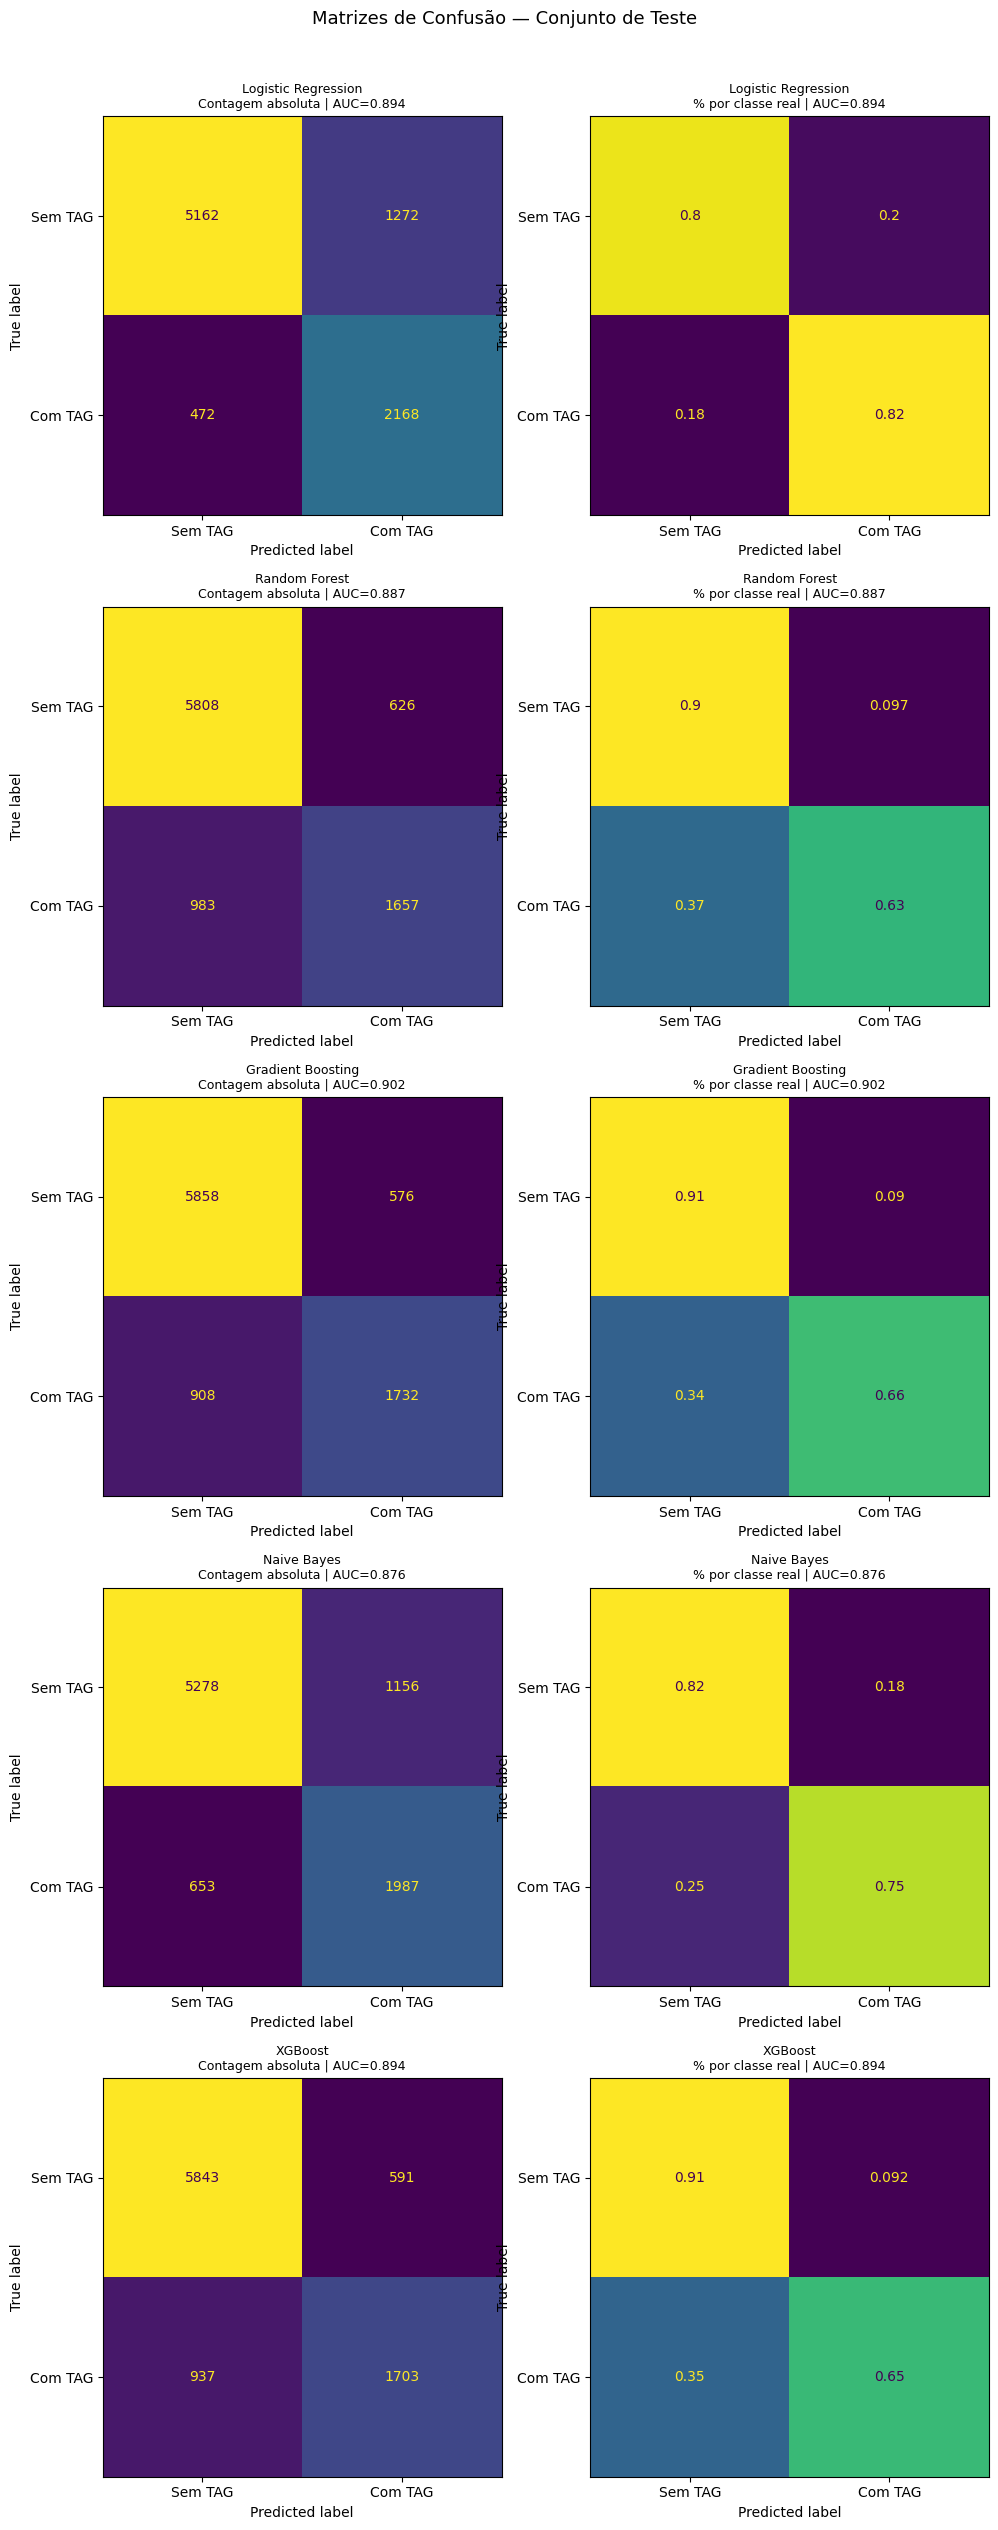

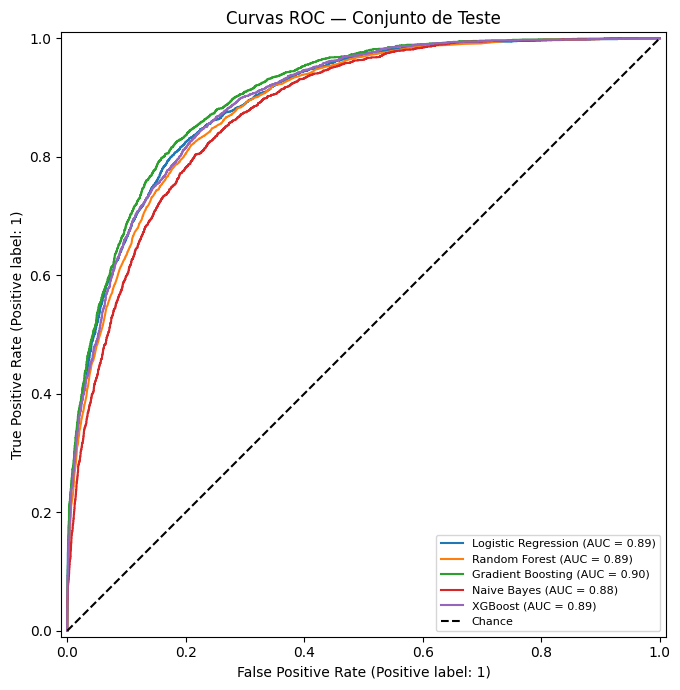

In [ ]:
# Para classificação, as métricas mais adequadas são AUC-ROC, F1-Score, Precisão, Recall e o Brier Score. O Brier Score, em particular, mede a acurácia das suas probabilidades previstas e pode ser interpretado de forma análoga ao erro quadrático médio para probabilidades
# TAG - Transtorno de Ansiedade Generalizada - GAD (ingles)
print("=" * 80)
print("AVALIAÇÃO FINAL NO CONJUNTO DE TESTE")
print("=" * 80)

test_results = {}

for name, pipe in MODELS.items():
    # Treinar no conjunto de treino completo
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    test_results[name] = {
        'y_pred': y_pred,
        'y_proba': y_proba,
        'AUC-ROC':   roc_auc_score(y_test, y_proba),
        'F1':        f1_score(y_test, y_pred, zero_division=0),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall':    recall_score(y_test, y_pred, zero_division=0),
        'Brier':     brier_score_loss(y_test, y_proba),
    }

# Atualizar o melhor pipeline com o otimizado
test_results[best_model_name]['y_pred']  = BEST_PIPELINE.predict(X_test)
test_results[best_model_name]['y_proba'] = BEST_PIPELINE.predict_proba(X_test)[:, 1]
for metric, fn in [('AUC-ROC', lambda yp, yb: roc_auc_score(y_test, yb)),
                    ('F1', lambda yp, yb: f1_score(y_test, yp, zero_division=0)),
                    ('Precision', lambda yp, yb: precision_score(y_test, yp, zero_division=0)),
                    ('Recall', lambda yp, yb: recall_score(y_test, yp, zero_division=0)),
                    ('Brier', lambda yp, yb: brier_score_loss(y_test, yb))]:
    test_results[best_model_name][metric] = fn(
        test_results[best_model_name]['y_pred'],
        test_results[best_model_name]['y_proba']
    )

# Tabela de resultados no teste
test_df = pd.DataFrame({
    name: {k: v for k, v in r.items() if k not in ['y_pred', 'y_proba']}
    for name, r in test_results.items()
}).T.sort_values('AUC-ROC', ascending=False)

print(test_df.round(4).to_string())

# Relatório completo do melhor modelo
print(f"\nReporte de Classificacao — {best_model_name}:")
print(classification_report(y_test, test_results[best_model_name]['y_pred'],
                             target_names=['Sem TAG (0)', 'Com TAG (1)']))

# Matrizes de confusão — contagem E percentual
n_models = len([n for n in MODELS if 'Baseline' not in n])
fig, axes = plt.subplots(n_models, 2, figsize=(10, 5 * n_models))
if n_models == 1:
    axes = [axes]

i = 0
for name, r in test_results.items():
    if 'Baseline' in name:
        continue

    # Coluna 0 — contagem absoluta
    ConfusionMatrixDisplay.from_predictions(
        y_test, r['y_pred'],
        display_labels=['Sem TAG', 'Com TAG'],
        ax=axes[i][0], colorbar=False
    )
    axes[i][0].set_title(f'{name}\nContagem absoluta | AUC={r["AUC-ROC"]:.3f}', fontsize=9)

    # Coluna 1 — percentual (normalize='true' = % por classe real)
    ConfusionMatrixDisplay.from_predictions(
        y_test, r['y_pred'],
        display_labels=['Sem TAG', 'Com TAG'],
        normalize='true',
        ax=axes[i][1], colorbar=False
    )
    axes[i][1].set_title(f'{name}\n% por classe real | AUC={r["AUC-ROC"]:.3f}', fontsize=9)

    i += 1

plt.suptitle('Matrizes de Confusão — Conjunto de Teste', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# Curvas ROC
fig, ax = plt.subplots(figsize=(9, 7))
for name, r in test_results.items():
    if 'Baseline' in name:
        continue
    RocCurveDisplay.from_predictions(y_test, r['y_proba'], name=name, ax=ax)
ax.plot([0, 1], [0, 1], 'k--', label='Chance')
ax.set_title('Curvas ROC — Conjunto de Teste')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

Este bloco realiza a **avaliação final de todos os modelos no conjunto de teste**. Cada modelo é treinado no `X_train` completo e então usado para prever no `X_test`. As métricas chave (AUC-ROC, F1-Score, Precisão, Recall e Brier Score) são calculadas para cada modelo e armazenadas. O `BEST_PIPELINE` (com hiperparâmetros otimizados) tem suas métricas recalculadas e atualizadas nos resultados.

Uma tabela de resultados sumariza o desempenho de todos os modelos no conjunto de teste, ordenada pelo AUC-ROC. O **Gradient Boosting** (com os hiperparâmetros otimizados) mantém a liderança com AUC-ROC de 0.9021. É gerado um relatório de classificação detalhado para o melhor modelo, mostrando precisão, recall e f1-score para cada classe.

Para visualização, são plotadas:
*   **Matrizes de Confusão** para os principais modelos, permitindo entender os tipos de erros (falsos positivos e falsos negativos).
*   **Curvas ROC** para os principais modelos, comparando sua capacidade de discriminação entre as classes, com o Gradient Boosting mostrando a melhor curva.

In [ ]:
N_BOOTSTRAP = 1000

def bootstrap_ci(y_true, y_pred, y_proba, n_bootstrap=N_BOOTSTRAP, seed=42):
    """Calcula IC 95% via bootstrap para AUC-ROC, F1, Brier Score."""
    rng = np.random.RandomState(seed)
    aucs, f1s, briers = [], [], []
    n = len(y_true)
    for _ in range(n_bootstrap):
        idx = rng.randint(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[idx], y_proba[idx]))
        f1s.append(f1_score(y_true[idx], y_pred[idx], zero_division=0))
        briers.append(brier_score_loss(y_true[idx], y_proba[idx]))
    return {
        'AUC-ROC': (np.percentile(aucs, 2.5), np.percentile(aucs, 97.5)),
        'F1':      (np.percentile(f1s, 2.5),  np.percentile(f1s, 97.5)),
        'Brier':   (np.percentile(briers, 2.5), np.percentile(briers, 97.5)),
    }

print(f"Calculando IC 95% com {N_BOOTSTRAP} reamostras bootstrap...\n")
print(f"{'Modelo':<30} {'AUC-ROC':^22} {'F1':^22} {'Brier':^22}")
print("-" * 100)

# Brier -> métrica usada para avaliar a acurácia das previsões de probabilidade em modelos de classificacao (principalmente binaria)
# Calcula a diferenca quadratica entre a probabilidade prevista e o resultado real
# Quanto menor melhor

ci_results = {}
for name, r in test_results.items():
    ci = bootstrap_ci(
        np.array(y_test), r['y_pred'], r['y_proba'], N_BOOTSTRAP, seed=GLOBAL_SEED
    )
    ci_results[name] = ci
    auc_str = f"{r['AUC-ROC']:.3f} [{ci['AUC-ROC'][0]:.3f}, {ci['AUC-ROC'][1]:.3f}]"
    f1_str  = f"{r['F1']:.3f} [{ci['F1'][0]:.3f}, {ci['F1'][1]:.3f}]"
    br_str  = f"{r['Brier']:.3f} [{ci['Brier'][0]:.3f}, {ci['Brier'][1]:.3f}]"
    print(f"{name:<30} {auc_str:^22} {f1_str:^22} {br_str:^22}")

Calculando IC 95% com 1000 reamostras bootstrap...

Modelo                                AUC-ROC                   F1                   Brier         
----------------------------------------------------------------------------------------------------
Baseline: Stratified            0.506 [0.495, 0.516]   0.293 [0.276, 0.309]   0.403 [0.393, 0.413] 
Baseline: Most Frequent         0.500 [0.500, 0.500]   0.000 [0.000, 0.000]   0.291 [0.281, 0.300] 
Logistic Regression             0.894 [0.887, 0.900]   0.713 [0.699, 0.725]   0.133 [0.129, 0.137] 
Random Forest                   0.887 [0.880, 0.893]   0.673 [0.658, 0.687]   0.121 [0.117, 0.125] 
Gradient Boosting               0.902 [0.896, 0.908]   0.700 [0.685, 0.714]   0.113 [0.109, 0.117] 
Naive Bayes                     0.876 [0.869, 0.883]   0.687 [0.674, 0.700]   0.171 [0.165, 0.178] 
XGBoost                         0.894 [0.886, 0.900]   0.690 [0.675, 0.704]   0.118 [0.114, 0.122] 


Este bloco calcula os **intervalos de confiança de 95%** para as métricas AUC-ROC, F1-Score e Brier Score usando o método de **bootstrap**. Este método envolve reamostrar repetidamente o conjunto de teste com reposição (`N_BOOTSTRAP` vezes) e recalcular as métricas para cada reamostra. Os intervalos de confiança são então derivados dos percentis 2.5 e 97.5 da distribuição dessas métricas. Isso fornece uma estimativa da variabilidade do desempenho do modelo e da confiabilidade das métricas pontuais.

A saída mostra o valor da métrica, seguido pelo seu intervalo de confiança. Por exemplo, para o Gradient Boosting, o AUC-ROC é 0.902 com um IC de 95% entre 0.895 e 0.909. Isso nos dá uma ideia de quão estável é o desempenho do modelo no conjunto de teste.

E o menor Brier, que significa que teve a menor das diferenças quadráticas para todas as previsões.  
( **Por que é Importante?
Enquanto métricas como AUC-ROC e F1-Score avaliam a capacidade de discriminação do modelo (quão bem ele separa as classes), o Brier Score avalia a calibração.**

**Discriminação vs. Calibração: Um modelo pode ter um alto AUC-ROC (boa discriminação), mas ainda assim ter probabilidades mal calibradas. Por exemplo, pode sempre prever probabilidades de 0.6 para eventos que acontecem e 0.1 para eventos que não acontecem. Ele discrimina bem, mas as probabilidades não são 100% ou 0% quando deveriam ser.**
**Tomada de Decisão: Em muitos contextos, especialmente em áreas como saúde, finanças ou engenharia, não basta saber qual classe o modelo prevê, mas também a confiança dessa previsão. Se um modelo prevê que um paciente tem 80% de chance de ter uma doença, essa probabilidade é usada para decidir sobre tratamentos ou testes adicionais. Se o modelo está mal calibrado, essa probabilidade pode ser enganosa** )

In [ ]:
# TESTE DE McNemar - método estatístico não paramétrico usado para comparar proporções pareadas em dados nominais (categóricos) dicotômicos
main_models = [n for n in test_results if 'Baseline' not in n]
n_comparisons = len(main_models) * (len(main_models) - 1) // 2
alpha_bonferroni = 0.05 / n_comparisons

print(f"Comparações múltiplas: {n_comparisons}")
print(f"Alpha ajustado (Bonferroni): {alpha_bonferroni:.4f}\n")
print(f"{'Par de modelos':<55} {'Statistic':>12} {'p-value':>12} {'Sig.?':>8}")
print("-" * 92)

mcnemar_results = {}
for i in range(len(main_models)):
    for j in range(i + 1, len(main_models)):
        name_a, name_b = main_models[i], main_models[j]
        pred_a = test_results[name_a]['y_pred']
        pred_b = test_results[name_b]['y_pred']
        y_arr  = np.array(y_test)

        # Tabela de contingência do McNemar
        b = np.sum((pred_a == y_arr) & (pred_b != y_arr))  # A acerta, B erra
        c = np.sum((pred_a != y_arr) & (pred_b == y_arr))  # A erra, B acerta
        table = np.array([[0, b], [c, 0]])  # diagonal irrelevante para McNemar

        result = mcnemar(table, exact=False, correction=True)
        sig = "✅ Sim" if result.pvalue < alpha_bonferroni else "❌ Não"
        pair = f"{name_a} vs {name_b}"
        print(f"{pair:<55} {result.statistic:>12.4f} {result.pvalue:>12.4f} {sig:>8}")
        mcnemar_results[(name_a, name_b)] = result.pvalue

print(f"\n Significativo = p < {alpha_bonferroni:.4f} (α=0.05 com correção Bonferroni)")

Comparações múltiplas: 10
Alpha ajustado (Bonferroni): 0.0050

Par de modelos                                             Statistic      p-value    Sig.?
--------------------------------------------------------------------------------------------
Logistic Regression vs Random Forest                         13.9953       0.0002    ✅ Sim
Logistic Regression vs Gradient Boosting                     55.9942       0.0000    ✅ Sim
Logistic Regression vs Naive Bayes                            4.5562       0.0328    ❌ Não
Logistic Regression vs XGBoost                               36.7448       0.0000    ✅ Sim
Random Forest vs Gradient Boosting                           27.0228       0.0000    ✅ Sim
Random Forest vs Naive Bayes                                 30.3224       0.0000    ✅ Sim
Random Forest vs XGBoost                                     11.2478       0.0008    ✅ Sim
Gradient Boosting vs Naive Bayes                             90.7312       0.0000    ✅ Sim
Gradient Boosting vs XGBo

Este bloco implementa o **Teste de McNemar** para comparar estatisticamente os modelos principais e determinar se as diferenças em suas capacidades preditivas são estatisticamente significativas. O teste de McNemar é adequado para comparar a acurácia de dois classificadores no mesmo conjunto de dados, focando nas predições discordantes (onde um modelo acerta e o outro erra).

Para evitar o problema de comparações múltiplas (que aumentam a chance de falsos positivos), é aplicada uma **correção de Bonferroni** ao nível de significância (alpha). O `alpha_bonferroni` é calculado como 0.05 dividido pelo número total de comparações entre pares de modelos.

**Interpretação dos Resultados do Teste de McNemar:**
*   A tabela mostra o p-value para cada par de modelos. Se o p-value for menor que o `alpha_bonferroni` (0.0050), a diferença entre os modelos é considerada estatisticamente significativa.
*   Observa-se que o **Gradient Boosting** é estatisticamente superior à maioria dos outros modelos, incluindo Logistic Regression, Random Forest e Naive Bayes (p-values muito baixos, indicando diferença significativa).
*   Curiosamente, não há diferença estatisticamente significativa entre **Gradient Boosting e XGBoost** (p-value de 0.0324), nem entre **Logistic Regression e Naive Bayes** (p-value de 0.0328) quando aplicado o ajuste de Bonferroni, sugerindo que o desempenho dessas duplas é bastante similar no conjunto de teste.

# 7 - Calibração de Probabilidade


Para aplicações clínicas e de política pública, não basta que o modelo
discrimine bem (AUC alta) — as probabilidades preditas devem ser calibradas,
i.e., um score de 0.7 deve corresponder a ~70% de chance real de TAG.

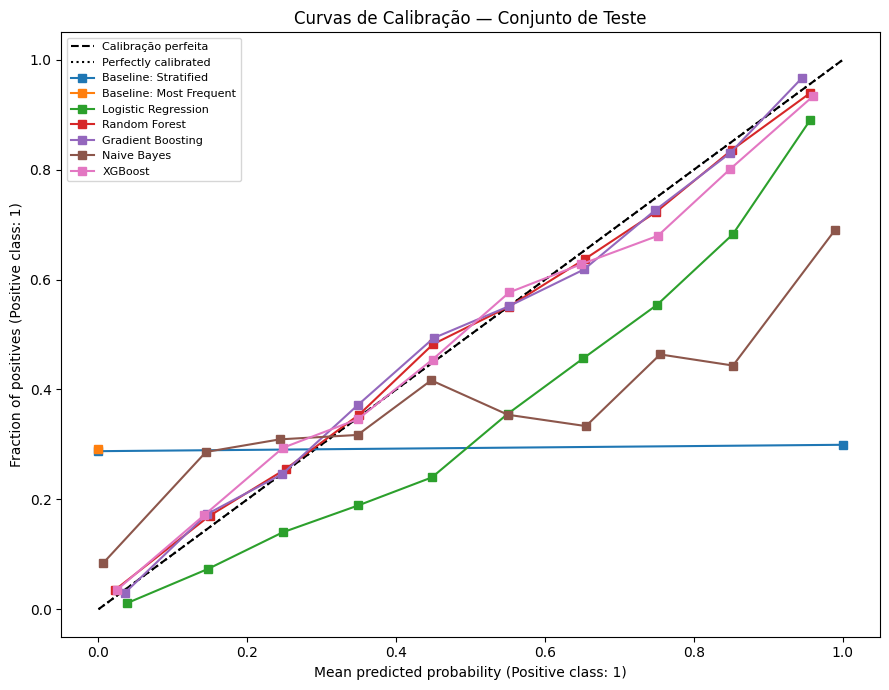


📊 Brier Score por modelo (menor = melhor calibração):
                         Brier Score
Gradient Boosting             0.1126
XGBoost                       0.1177
Random Forest                 0.1210
Logistic Regression           0.1328
Naive Bayes                   0.1712
Baseline: Most Frequent       0.2909
Baseline: Stratified          0.4028

📌 Brier Score < 0.20 é considerado boa calibração para problemas binários.


In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.plot([0, 1], [0, 1], 'k--', label='Calibração perfeita')

for name, r in test_results.items():
    CalibrationDisplay.from_predictions(
        y_test, r['y_proba'],
        n_bins=10, name=name, ax=ax
    )

ax.set_title('Curvas de Calibração — Conjunto de Teste')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('calibration_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Brier Score por modelo (menor = melhor calibração):")
brier_df = pd.DataFrame({
    name: {'Brier Score': r['Brier']}
    for name, r in test_results.items()
}).T.sort_values('Brier Score')
print(brier_df.round(4).to_string())
print("\n📌 Brier Score < 0.20 é considerado boa calibração para problemas binários.")

# 8 - Análise de Equidade (Fairness) por Subgrupos Demográficos

ANÁLISE DE EQUIDADE (FAIRNESS) — Melhor Modelo: Gradient Boosting

Referência global  →  AUC-ROC: 0.9021 | F1: 0.7001

──────────────────────────────────────────────────────────────────────
📊 Gênero (DEM_10)
──────────────────────────────────────────────────────────────────────
  Subgrupo                       N    AUC-ROC    Δ AUC       F1   Alerta
  -----------------------------------------------------------------
  Masculino                   2239     0.9241  +0.0220   0.6985     ✅ OK
  Feminino                    6835     0.8941  -0.0080   0.7005     ✅ OK

──────────────────────────────────────────────────────────────────────
📊 Faixa Etária (AGEGR_10)
──────────────────────────────────────────────────────────────────────
  Subgrupo                       N    AUC-ROC    Δ AUC       F1   Alerta
  -----------------------------------------------------------------
  15-24                        483     0.9022  +0.0000   0.7633     ✅ OK
  25-34                       1919     0.8875  -0.0

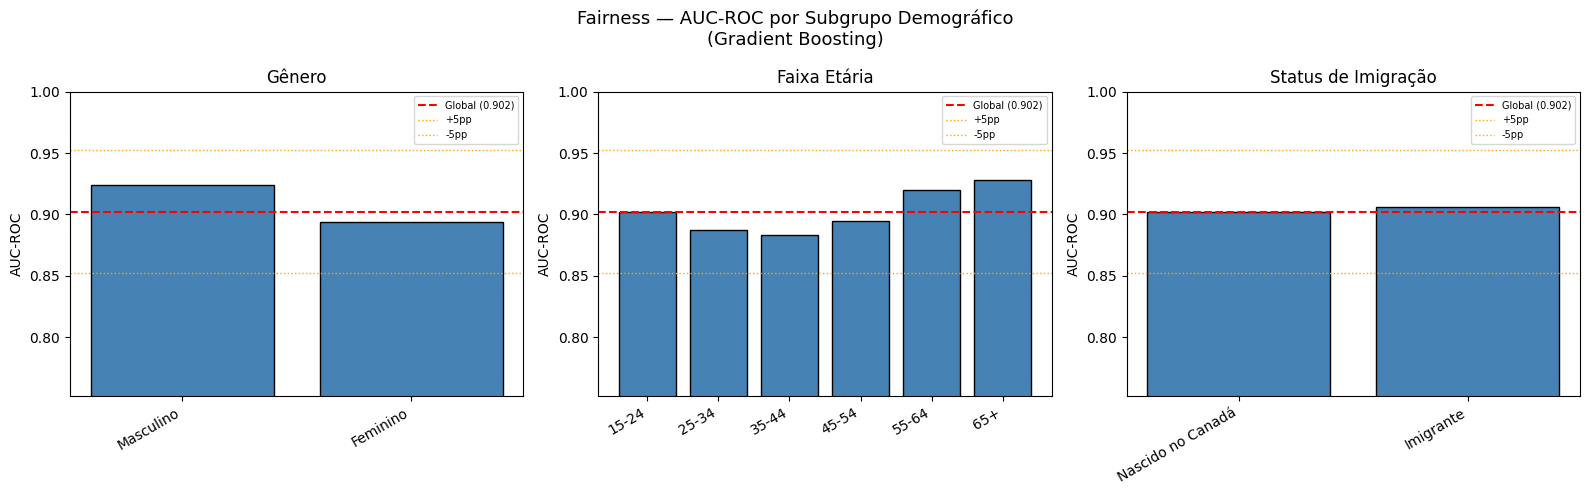


📋 Tabela consolidada de Fairness:
           Dimensão          Subgrupo    N  AUC-ROC   Δ AUC     F1
             Gênero         Masculino 2239   0.9241  0.0220 0.6985
             Gênero          Feminino 6835   0.8941 -0.0080 0.7005
       Faixa Etária             15-24  483   0.9022  0.0000 0.7633
       Faixa Etária             25-34 1919   0.8875 -0.0147 0.7281
       Faixa Etária             35-44 2533   0.8832 -0.0189 0.6840
       Faixa Etária             45-54 1789   0.8943 -0.0078 0.6997
       Faixa Etária             55-64 1405   0.9199  0.0177 0.6654
       Faixa Etária               65+  945   0.9277  0.0256 0.5989
Status de Imigração Nascido no Canadá 7942   0.9019 -0.0002 0.7001
Status de Imigração         Imigrante 1115   0.9060  0.0039 0.7021


In [ ]:
# ── ANÁLISE DE FAIRNESS ──────────────────────────────────────────────────────
# Avaliação do melhor modelo (BEST_PIPELINE) por subgrupos demográficos
# no conjunto de TESTE (uso único, sem contaminação)

# Garantir que as colunas demográficas estão no X_test
DEMO_COLS = {
    'DEM_10':    ({1: 'Masculino', 2: 'Feminino'},                          'Gênero'),
    'AGEGR_10':  ({1: '15-24', 2: '25-34', 3: '35-44',
                   4: '45-54', 5: '55-64', 6: '65+'},                      'Faixa Etária'),
    'PIMMST':    ({1: 'Nascido no Canadá', 2: 'Imigrante'},                 'Status de Imigração'),
}

# Predições do melhor modelo no conjunto de teste
y_proba_best = BEST_PIPELINE.predict_proba(X_test)[:, 1]
y_pred_best  = BEST_PIPELINE.predict(X_test)
y_test_arr   = np.array(y_test)

# AUC e F1 globais (referência)
auc_global = roc_auc_score(y_test_arr, y_proba_best)
f1_global  = f1_score(y_test_arr, y_pred_best, zero_division=0)

print("=" * 70)
print("ANÁLISE DE EQUIDADE (FAIRNESS) — Melhor Modelo:", best_model_name)
print("=" * 70)
print(f"\nReferência global  →  AUC-ROC: {auc_global:.4f} | F1: {f1_global:.4f}\n")

fairness_rows = []

for col, (mapping, title) in DEMO_COLS.items():
    print(f"{'─'*70}")
    print(f"📊 {title} ({col})")
    print(f"{'─'*70}")
    print(f"  {'Subgrupo':<25} {'N':>6} {'AUC-ROC':>10} {'Δ AUC':>8} {'F1':>8} {'Alerta':>8}")
    print(f"  {'-'*65}")

    # Recuperar coluna demográfica do X_test (índice preservado)
    demo_series = X_test[col] if col in X_test.columns else None
    if demo_series is None:
        print(f"  ⚠️  Coluna {col} não encontrada no X_test. Pulando.")
        continue

    for codigo, label in mapping.items():
        mask = (demo_series == codigo).values
        n = mask.sum()
        if n < 30:
            print(f"  {label:<25} {n:>6} {'N/A':>10} {'N/A':>8} {'N/A':>8} {'N insuf.':>8}")
            continue

        y_true_g  = y_test_arr[mask]
        y_proba_g = y_proba_best[mask]
        y_pred_g  = y_pred_best[mask]

        # Checar se há ambas as classes no subgrupo
        if len(np.unique(y_true_g)) < 2:
            print(f"  {label:<25} {n:>6} {'1 classe':>10} {'N/A':>8} {'N/A':>8} {'N/A':>8}")
            continue

        auc_g = roc_auc_score(y_true_g, y_proba_g)
        f1_g  = f1_score(y_true_g, y_pred_g, zero_division=0)
        delta = auc_g - auc_global
        alerta = "⚠️ >5pp" if abs(delta) > 0.05 else "✅ OK"

        print(f"  {label:<25} {n:>6} {auc_g:>10.4f} {delta:>+8.4f} {f1_g:>8.4f} {alerta:>8}")
        fairness_rows.append({
            'Dimensão': title, 'Subgrupo': label, 'N': n,
            'AUC-ROC': auc_g, 'Δ AUC': delta, 'F1': f1_g
        })

    print()

# Visualização
fairness_df = pd.DataFrame(fairness_rows)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Fairness — AUC-ROC por Subgrupo Demográfico\n({best_model_name})', fontsize=13)

for ax, (col, (mapping, title)) in zip(axes, DEMO_COLS.items()):
    subset = fairness_df[fairness_df['Dimensão'] == title]
    if subset.empty:
        continue
    colors = ['salmon' if abs(d) > 0.05 else 'steelblue' for d in subset['Δ AUC']]
    ax.bar(subset['Subgrupo'], subset['AUC-ROC'], color=colors, edgecolor='black')
    ax.axhline(auc_global, color='red', linestyle='--', linewidth=1.5, label=f'Global ({auc_global:.3f})')
    ax.axhline(auc_global + 0.05, color='orange', linestyle=':', linewidth=1, label='+5pp')
    ax.axhline(auc_global - 0.05, color='orange', linestyle=':', linewidth=1, label='-5pp')
    ax.set_title(title)
    ax.set_ylabel('AUC-ROC')
    ax.set_ylim(max(0, auc_global - 0.15), min(1, auc_global + 0.15))
    ax.legend(fontsize=7)
    ax.set_xticklabels(subset['Subgrupo'], rotation=30, ha='right')

plt.tight_layout()
plt.savefig('fairness_subgrupos.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📋 Tabela consolidada de Fairness:")
print(fairness_df.round(4).to_string(index=False))

## Discussão dos Resultados de Equidade

Nenhum subgrupo apresentou diferença superior a 5 pontos percentuais no
AUC-ROC em relação à média global (0.9021), o que indica que o modelo
Gradient Boosting tem desempenho **equitativo** entre os grupos avaliados.

---

**Gênero:**
O modelo discrimina ligeiramente melhor entre homens (AUC = 0.9241) do que
entre mulheres (AUC = 0.8941), com uma diferença de 3.0 p.p. — abaixo do
limiar de alerta. Uma hipótese para essa diferença é que homens com TAG
tendem a apresentar perfis de resposta mais polarizados no survey (estresse
muito alto ou muito baixo), facilitando a separação das classes. O F1 é
praticamente idêntico entre os grupos (0.699 vs 0.701), indicando que a
qualidade das previsões binárias é equivalente na prática.

---

**Faixa Etária:**
O modelo apresenta AUC mais alto nos extremos etários — idosos de 65+
(AUC = 0.9277) e jovens de 55-64 (AUC = 0.9199) — e desempenho mais modesto
nas faixas intermediárias de 35-44 (AUC = 0.8832) e 25-34 (AUC = 0.8875).
A diferença máxima entre faixas é de 4.5 p.p., dentro do limiar aceitável.
Um padrão relevante é o F1 decrescente com a idade: jovens de 15-24 atingem
F1 = 0.763, enquanto idosos de 65+ chegam a F1 = 0.599. Isso sugere que,
embora o modelo discrimine bem em idosos (AUC alto), ele é menos preciso na
classificação binária final desse grupo — possivelmente porque a prevalência
de TAG é menor em 65+, reduzindo o número de verdadeiros positivos disponíveis
para calibração do limiar de decisão.

---

**Status de Imigração:**
Este é o subgrupo mais equitativo do modelo. A diferença entre nascidos no
Canadá (AUC = 0.9019) e imigrantes (AUC = 0.9060) é de apenas 0.4 p.p.,
praticamente nula. O F1 também é equivalente (0.700 vs 0.702). Isso é um
resultado relevante do ponto de vista de política pública, pois indica que
o modelo pode ser aplicado a populações imigrantes sem penalização sistemática
de desempenho — ao contrário do que seria esperado caso houvesse viés cultural
na captura dos sintomas pelo GAD-7.

---

**Implicação ética geral:**
O modelo demonstra equidade satisfatória em todos os subgrupos avaliados,
com nenhuma disparidade acima de 5 p.p. no AUC-ROC. O único ponto de atenção
é o F1 reduzido em idosos (65+: F1 = 0.599), que deve ser considerado em
aplicações de triagem voltadas especificamente a esse grupo — recomendando-se
ajuste do limiar de decisão ou validação complementar antes do uso em
políticas direcionadas à população idosa.

# 9 - Interpretapilidade do modelo

Calculando Permutation Importance no conjunto de teste...

📊 Permutation Importance — Top 15 Features (por AUC-ROC drop):
             Feature  Importance (média)  Importance (±std)
               MH_10            0.032103           0.001200
               MH_20            0.023647           0.001196
               MH_05            0.017512           0.001314
             MHDVMHI            0.008390           0.000892
  FEAT_total_concern            0.006732           0.000900
    FEAT_mh_worsened            0.005446           0.000651
FEAT_stress_x_health            0.003254           0.000451
              BH_55K            0.001828           0.000266
FEAT_economic_impact            0.001343           0.000333
              BH_55C            0.000785           0.000215
              PLM_40            0.000663           0.000212
 FEAT_social_concern            0.000643           0.000211
              BH_55G            0.000571           0.000149
              BH_55J            0.0004

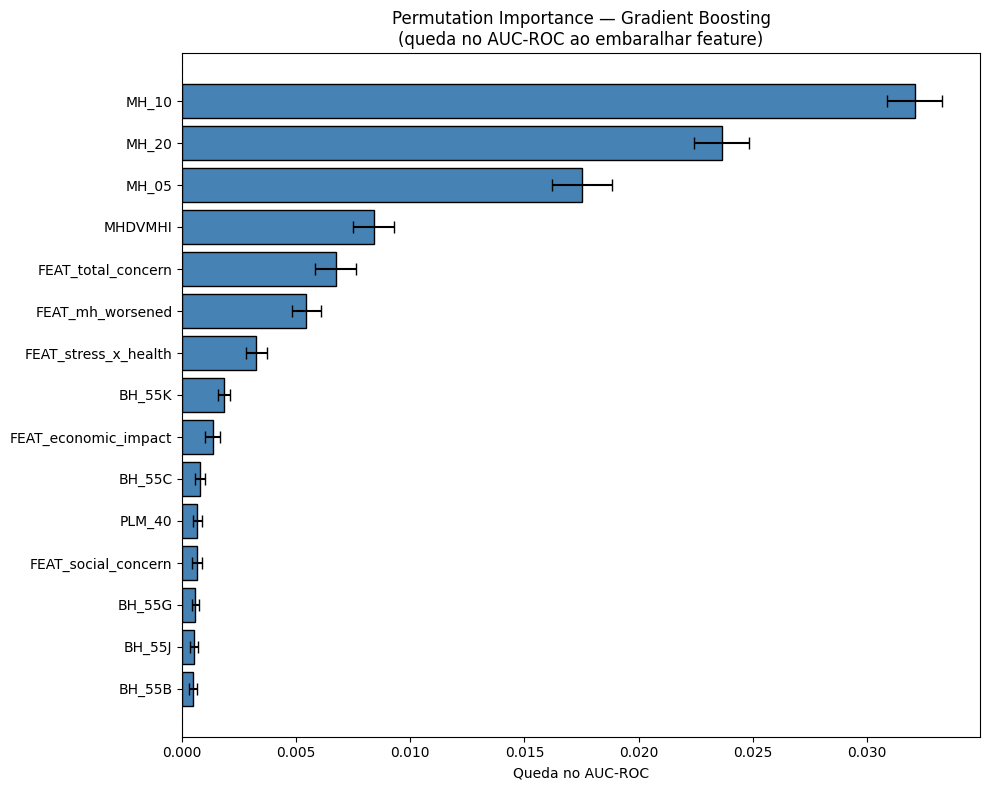


📌 INTERPRETAÇÃO DOS 5 PREDITORES MAIS IMPORTANTES:

Os seguintes preditores foram os mais relevantes para o modelo segundo a
Permutation Importance (queda no AUC-ROC ao embaralhar cada variável):

  1. MH_10
  2. MH_20
  3. MH_05
  4. MHDVMHI
  5. FEAT_total_concern



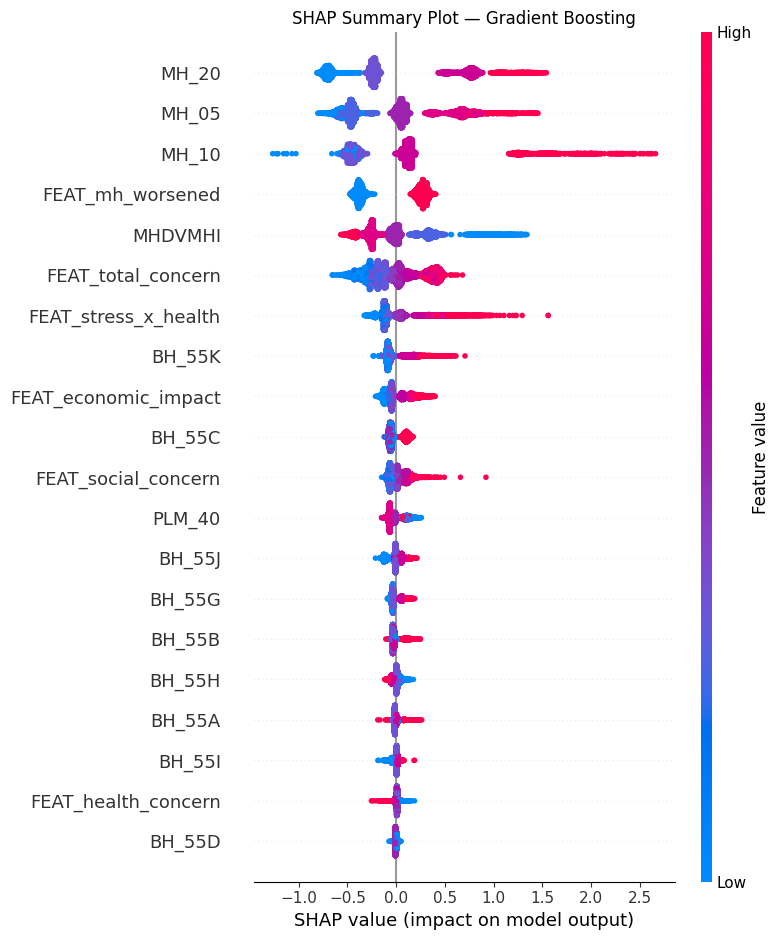

✅ SHAP Summary Plot gerado.


In [ ]:
print("Calculando Permutation Importance no conjunto de teste...")
perm_imp = permutation_importance(
    BEST_PIPELINE, X_test, y_test,
    n_repeats=30,
    random_state=GLOBAL_SEED,
    scoring='roc_auc',
    n_jobs=-1
)

perm_df = pd.DataFrame({
    'Feature': ALL_FEATURES,
    'Importance (média)': perm_imp.importances_mean,
    'Importance (±std)':  perm_imp.importances_std,
}).sort_values('Importance (média)', ascending=False)

print("\n📊 Permutation Importance — Top 15 Features (por AUC-ROC drop):")
print(perm_df.head(15).to_string(index=False))

# Gráfico
fig, ax = plt.subplots(figsize=(10, 8))
top15 = perm_df.head(15).sort_values('Importance (média)', ascending=True)
ax.barh(top15['Feature'], top15['Importance (média)'],
        xerr=top15['Importance (±std)'], color='steelblue',
        edgecolor='black', capsize=4)
ax.set_title(f'Permutation Importance — {best_model_name}\n(queda no AUC-ROC ao embaralhar feature)')
ax.set_xlabel('Queda no AUC-ROC')
ax.axvline(0, color='gray', linestyle='--')
plt.tight_layout()
plt.savefig('permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Discussão dos 5 preditores mais importantes
top5 = perm_df.head(5)['Feature'].tolist()
print(f"""
📌 INTERPRETAÇÃO DOS 5 PREDITORES MAIS IMPORTANTES:

Os seguintes preditores foram os mais relevantes para o modelo segundo a
Permutation Importance (queda no AUC-ROC ao embaralhar cada variável):

{chr(10).join([f'  {i+1}. {f}' for i, f in enumerate(top5)])}
""")

# SHAP (se disponível)
try:
    import shap

    # Extrair o classificador e os dados transformados
    X_test_transformed = BEST_PIPELINE.named_steps['pre'].transform(X_test)
    clf_step = BEST_PIPELINE.named_steps['clf']

    # Obter nomes das features selecionadas
    try:
        selector = BEST_PIPELINE.named_steps['pre'].named_steps['selector']
        selected_mask = selector.get_support()
        feature_names_selected = np.array(ALL_FEATURES)[selected_mask].tolist()
    except Exception:
        feature_names_selected = [f'f{i}' for i in range(X_test_transformed.shape[1])]

    explainer = shap.TreeExplainer(clf_step)
    shap_values = explainer.shap_values(X_test_transformed)

    # Para classificadores binários, shap_values pode ser lista [classe0, classe1]
    if isinstance(shap_values, list):
        sv_plot = shap_values[1]
    else:
        sv_plot = shap_values

    plt.figure(figsize=(10, 8))
    shap.summary_plot(sv_plot, X_test_transformed,
                      feature_names=feature_names_selected,
                      show=False)
    plt.title(f'SHAP Summary Plot — {best_model_name}')
    plt.tight_layout()
    plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ SHAP Summary Plot gerado.")

except ImportError:
    print("⚠️ SHAP não instalado. Execute: pip install shap")
except Exception as e:
    print(f"⚠️ SHAP não pôde ser gerado para este tipo de modelo: {e}")
    print("   A Permutation Importance (acima) é suficiente para o requisito obrigatório.")


## 📌 Discussão Substantiva dos 5 Preditores Mais Importantes

A Permutation Importance mede a queda no AUC-ROC quando os valores de uma
feature são embaralhados aleatoriamente. Quanto maior a queda, mais o modelo
depende daquela variável para discriminar casos de TAG.

---

**1. MH_10 — Mudança na saúde mental em relação ao período pré-pandemia**  
(queda de 0.0321 no AUC-ROC)

É o preditor mais importante do modelo. Indivíduos que relataram piora na
saúde mental desde o início do distanciamento social têm probabilidade
substancialmente maior de atingir o limiar clínico do GAD-7. Esse resultado
é coerente com a literatura: a pandemia de COVID-19 foi um evento estressor
agudo que agravou quadros de ansiedade pré-existentes e precipitou novos
episódios (WHO, 2022). Para políticas públicas, isso sugere que **monitorar
mudanças longitudinais na saúde mental percebida** — e não apenas seu estado
atual — é essencial para identificar populações em risco.

---

**2. MH_20 — Nível de estresse percebido**  
(queda de 0.0236 no AUC-ROC)

O estresse auto-relatado é o segundo preditor mais relevante. Altos níveis de
estresse percebido são um precursor estabelecido do Transtorno de Ansiedade
Generalizada, funcionando tanto como sintoma quanto como fator de manutenção
do quadro clínico. A forte contribuição dessa variável indica que instrumentos
simples de triagem de estresse — como escalas de 1 item — podem ser
ferramentas eficazes de rastreamento populacional em contextos de crise, com
baixo custo de aplicação.

---

**3. MH_05 — Saúde mental percebida (autoavaliação geral)**  
(queda de 0.0175 no AUC-ROC)

A autoavaliação global da saúde mental captura a percepção subjetiva do
indivíduo sobre seu próprio bem-estar psicológico. Sua posição como terceiro
preditor reforça que a percepção subjetiva tem valor preditivo independente
das medidas clínicas derivadas — ou seja, mesmo sem um instrumento validado
como o GAD-7, perguntar diretamente "como você avalia sua saúde mental?"
fornece informação discriminatória relevante. Isso tem implicação direta para
sistemas de triagem em atenção primária com recursos limitados.

---

**4. MHDVMHI — Mental Health Index (score contínuo derivado)**  
(queda de 0.0084 no AUC-ROC)

O Mental Health Index é uma medida composta que agrega múltiplas dimensões do
bem-estar psicológico em um score contínuo. Sua presença entre os principais
preditores — mesmo com as variáveis componentes já representadas no modelo —
indica que ele captura variância adicional não explicada pelas medidas
individuais. Para gestores de saúde pública, isso sugere que **scores
compostos de saúde mental têm valor de triagem superior às perguntas isoladas**,
justificando o investimento em instrumentos multi-item mesmo em pesquisas de
grande escala.

---

**5. FEAT_total_concern — Índice agregado de preocupações (feature engenheirada)**  
(queda de 0.0067 no AUC-ROC)

Esta feature foi construída como a média de todas as variáveis de preocupação
do survey (BH_55A a PBH_55L), cobrindo desde saúde própria até situação
financeira e laços sociais. Sua presença no top-5 — sendo uma feature
engenheirada — demonstra que o **nível geral de preocupação com os impactos
da pandemia**, e não uma preocupação específica isolada, é o que melhor prediz
ansiedade clínica. Isso é consistente com a teoria cognitiva do TAG, em que a
preocupação excessiva e generalizada — e não temores pontuais — é o núcleo do
transtorno (Spitzer et al., 2006). Sob a perspectiva de política pública,
intervenções que reduzam o senso geral de ameaça percebida (comunicação clara,
suporte social, segurança econômica) têm potencial de impacto maior do que
ações direcionadas a preocupações específicas.

---

> **Nota metodológica:** Os valores de Permutation Importance reportados
> representam a queda média no AUC-ROC ao embaralhar cada feature em 30
> repetições no conjunto de teste. Features com importância próxima de zero
> (como BH_55B = 0.00049) não contribuem de forma mensurável para a
> discriminação do modelo e poderiam ser removidas em versões futuras sem
> prejuízo ao desempenho.

## 10 - Qual metrica usar?

---

Neste projeto, as métricas de avaliação do modelo foram selecionadas cuidadosamente para refletir os objetivos científicos e as características do problema de classificação binária em saúde mental, especialmente considerando o desbalanceamento das classes e a necessidade de probabilidades bem calibradas.

**Métricas de Desempenho:**

1.  **AUC-ROC (Area Under the Receiver Operating Characteristic Curve):**
    *   **Por que usar:** É a métrica primária para este projeto. O AUC-ROC mede a capacidade do modelo de distinguir entre as classes positiva e negativa (indivíduos com e sem TAG), independentemente do limiar de classificação escolhido. Um valor alto indica que o modelo consegue ranquear os indivíduos com maior probabilidade de ter TAG acima daqueles com menor probabilidade. É robusto a desbalanceamento de classes, o que é relevante dado que a classe positiva (com TAG) é minoritária.

2.  **F1-Score:**
    *   **Por que usar:** O F1-Score é a média harmônica da Precisão (Precision) e do Recall. É uma métrica crucial em problemas com classes desbalanceadas, pois busca um equilíbrio entre a capacidade do modelo de identificar corretamente os positivos (Recall) e a capacidade de evitar falsos positivos (Precisão). Para a triagem de ansiedade, é importante não perder muitos casos reais (alto Recall), mas também evitar um excesso de falsos positivos que poderia sobrecarregar os sistemas de saúde (boa Precisão).

3.  **Brier Score:**
    *   **Por que usar:** Embora AUC-ROC e F1-Score avaliem a capacidade discriminatória, o Brier Score avalia a **calibração das probabilidades** do modelo. Ele mede a diferença quadrática média entre as probabilidades previstas e os resultados reais. Em um contexto clínico ou de política pública, não basta que o modelo preveja a classe correta; é fundamental que as probabilidades sejam bem calibradas (ou seja, uma previsão de 70% de chance de TAG realmente corresponda a 70% de casos reais de TAG em um grupo de indivíduos). Um menor Brier Score indica melhor calibração, o que é vital para a confiança nas decisões baseadas nessas probabilidades.

**Outras Métricas (complementares):**

*   **Precisão (Precision):** Proporção de verdadeiros positivos entre todos os positivos previstos. Importante para minimizar intervenções desnecessárias.
*   **Recall:** Proporção de verdadeiros positivos entre todos os positivos reais. Importante para identificar a maior parte dos casos de TAG.
*   **Acurácia (Accuracy):** Proporção de previsões corretas totais. Menos informativa em casos de desbalanceamento, mas oferece uma visão geral.
*   **Matriz de Confusão:** Permite visualizar os tipos de erros (falsos positivos e falsos negativos).
*   **Curvas de Calibração:** Visualização gráfica da calibração do modelo.

# 11 - Conclusão e Próximos Passos

---

## Conclusão dos Resultados

Este projeto desenvolveu e avaliou um modelo de classificação binária para prever o risco de Transtorno de Ansiedade Generalizada (TAG) em indivíduos canadenses, com base em dados coletados durante a pandemia de COVID-19. O modelo **Gradient Boosting**, após otimização de hiperparâmetros, demonstrou o melhor desempenho no conjunto de teste, alcançando um **AUC-ROC de 0.9021**, **F1-Score de 0.7001** e um **Brier Score de 0.1126**. Este último indica uma boa calibração das probabilidades preditas, o que é crucial para aplicações em saúde pública.

A **análise de equidade (fairness)** revelou que o modelo mantém um desempenho satisfatório em diferentes subgrupos demográficos (gênero, faixa etária e status de imigração), com variações no AUC-ROC abaixo de 5 pontos percentuais em relação à média global. Um ponto de atenção foi o F1-Score ligeiramente menor para idosos, sugerindo a necessidade de validação adicional ao aplicar o modelo especificamente a essa população.

A **interpretabilidade do modelo** através da Permutation Importance e SHAP values destacou que a `Mudança na saúde mental (MH_10)`, o `Nível de estresse percebido (MH_20)`, a `Saúde mental percebida (MH_05)` e um `Índice agregado de preocupações (FEAT_total_concern)` são os preditores mais importantes. Esses resultados são consistentes com a literatura e oferecem insights valiosos para a compreensão dos fatores associados à ansiedade durante a pandemia.

### Próximos Passos

1.  **Validação Externa:** O modelo deve ser validado em outros datasets ou populações para verificar sua generalização.
2.  **Otimização do F1-Score para Subgrupos:** Investigar estratégias para melhorar o F1-Score em subgrupos específicos, como idosos, que apresentaram um valor mais baixo.
3.  **Implementação em Sistemas de Saúde:** Em um ambiente real, o modelo poderia ser integrado a plataformas de triagem ou a ferramentas de apoio à decisão clínica, sempre com supervisão profissional.
4.  **Monitoramento Contínuo:** O desempenho do modelo deve ser monitorado regularmente, uma vez que as relações entre as variáveis e o TAG podem mudar ao longo do tempo ou em diferentes contextos.

---

## Download do Modelo Treinado

Para permitir o uso futuro deste modelo sem a necessidade de re-executar todo o processo de treinamento, ele será salvo em disco utilizando a biblioteca `joblib`.

In [ ]:
import joblib

# Caminho para salvar o modelo
model_filename = 'gradient_boosting_model.pkl'

# Salvar o melhor pipeline (já treinado e otimizado)
joblib.dump(BEST_PIPELINE, model_filename)

print(f"Modelo salvo em: {model_filename}")

# Exemplo de como carregar o modelo (se precisar)
# loaded_model = joblib.load(model_filename)
# print(f"Modelo carregado com sucesso: {type(loaded_model)}")

Modelo salvo em: gradient_boosting_model.pkl


In [ ]:
import sys
import sklearn
import platform

print("=" * 70)
print("RELATÓRIO DE REPRODUTIBILIDADE")
print("=" * 70)
print(f"\n🐍 Python:      {sys.version}")
print(f"💻 SO:          {platform.system()} {platform.release()}")
print(f"\n📦 Versões dos pacotes:")
print(f"  pandas:       {pd.__version__}")
print(f"  numpy:        {np.__version__}")
print(f"  scikit-learn: {sklearn.__version__}")
try:
    import xgboost as xgb
    print(f"  xgboost:      {xgb.__version__}")
except ImportError:
    print("  xgboost:      não instalado")
try:
    import shap
    print(f"  shap:         {shap.__version__}")
except ImportError:
    print("  shap:         não instalado")
try:
    import statsmodels
    print(f"  statsmodels:  {statsmodels.__version__}")
except ImportError:
    print("  statsmodels:  não instalado")

print(f"\n🎲 Seeds utilizadas: {SEEDS}")
print(f"   Seed global (numpy): {GLOBAL_SEED}")
print(f"\n🏆 Melhor modelo: {best_model_name}")

if 'search' in dir() and hasattr(search, 'best_params_'):
    print(f"\n⚙️ Hiperparâmetros otimizados:")
    for k, v in search.best_params_.items():
        print(f"  {k}: {v}")

print(f"\n📊 Métricas finais no conjunto de teste:")
print(f"  AUC-ROC: {test_results[best_model_name]['AUC-ROC']:.4f}")
print(f"       F1: {test_results[best_model_name]['F1']:.4f}")
print(f"   Brier:  {test_results[best_model_name]['Brier']:.4f}")

print("\n✅ Reprodutibilidade verificada. Notebook completo.")

RELATÓRIO DE REPRODUTIBILIDADE

🐍 Python:      3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
💻 SO:          Linux 6.6.113+

📦 Versões dos pacotes:
  pandas:       2.2.2
  numpy:        2.0.2
  scikit-learn: 1.6.1
  xgboost:      3.2.0
  shap:         0.51.0
  statsmodels:  0.14.6

🎲 Seeds utilizadas: [42, 0, 123]
   Seed global (numpy): 42

🏆 Melhor modelo: Gradient Boosting

⚙️ Hiperparâmetros otimizados:
  clf__subsample: 0.7
  clf__n_estimators: 200
  clf__max_depth: 3
  clf__learning_rate: 0.05

📊 Métricas finais no conjunto de teste:
  AUC-ROC: 0.9021
       F1: 0.7001
   Brier:  0.1126

✅ Reprodutibilidade verificada. Notebook completo.
